# EcomIQ — exploratory data analysis

20 analyses across 8 sections, each answering a business question that changes
a decision. All plotting code is inline and visible so you can read, edit and
learn from it.

**Imports from `src/` are limited to code that is genuinely reused elsewhere:**
data loading, the two analysis frames, and shared plot styling. Those are
called again by segmentation, churn, forecasting and the dashboard, so they
must be importable modules. Chart code lives here, because each chart runs
once and is never called again.

### Before running

Activate the venv and select it as the notebook kernel in VS Code.
Then run every cell in order, starting from Step 0 below.


## Step 0 — make `src` importable

**Run this cell first, every time.** A notebook's working directory is
`notebooks/`, so Python cannot see `src/` one level up. This walks up the
folder tree until it finds the project root and adds it to the import path.

It needs no installation and no configuration, and it works no matter where
you put the notebook.

In [2]:
import sys
from pathlib import Path

# Walk up from the current folder until we find the one containing src/.
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "src").is_dir():
    raise RuntimeError(
        f"Could not find a 'src' folder above {Path.cwd()}.\n"
        "Is this notebook inside the project? Expected layout:\n"
        "    ecomiq/src/  and  ecomiq/notebooks/01_eda.ipynb"
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("project root :", ROOT)
print("src/ found   :", (ROOT / "src").is_dir())
print("CSVs in raw  :", len(list((ROOT / "data" / "raw").glob("*.csv"))), "of 9")

project root : c:\DS-AI-Spiced\EcomIQ_AI_Powered_Ecom_Platform
src/ found   : True
CSVs in raw  : 9 of 9


## Setup

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.data.load import check_integrity, load_all
from src.data.prepare import build_customer_frame, build_order_frame, category_labels
from src.viz.style import PALETTE, apply_style

apply_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Set False while iterating on a chart; True for a clean run that regenerates
# every PNG the README and dashboard reference.
SAVE_FIGURES = True
FIG_DIR = ROOT / "reports" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def show(fig, name):
    """Save (optionally) and return the figure so Jupyter renders it.

    Order matters: savefig writes the file, and returning fig lets the cell
    display it. Never call plt.close() here -- that destroys the figure before
    Jupyter can render it, which is why the project's save_fig() helper is not
    used in notebooks.
    """
    if SAVE_FIGURES:
        fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    return fig

print("setup complete")

setup complete


`%autoreload 2` re-imports changed modules on every cell run. Without it you
edit `src/data/prepare.py`, re-run, and silently get the old code.

## Load and audit the raw data

In [4]:
tables = load_all()

for name, df in tables.items():
    print(f"{name:22s} {df.shape[0]:>9,} x {df.shape[1]}")

customers                 99,441 x 5
orders                    99,441 x 8
order_items              112,650 x 7
order_payments           103,886 x 5
order_reviews             99,224 x 7
products                  32,951 x 9
sellers                    3,095 x 4
geolocation            1,000,163 x 5
category_translation          71 x 2


### Integrity audit

Run this before trusting anything downstream. Expect: zero orphaned foreign
keys, and 789 duplicate `review_id` values (an ID collision in the source --
the same review id appears against different orders, so reviews must be keyed
by `order_id`).

In [5]:
audit = check_integrity(tables)

display(audit[audit.check == "duplicate_primary_keys"][["table", "value", "detail"]])
display(audit[audit.check == "orphaned_foreign_keys"][["value", "detail"]])
display(audit[audit.check == "null_rate"][["table", "detail", "value"]].head(12))

,table,value,detail
1,customers,0.0,customer_id
3,orders,0.0,order_id
8,order_items,0.0,order_id + order_item_id
10,order_payments,0.0,order_id + payment_sequential
12,order_reviews,814.0,review_id
16,products,0.0,product_id
26,sellers,0.0,seller_id
29,category_translation,0.0,product_category_name


,value,detail
30,0.0,orders.customer_id -> customers.customer_id
31,0.0,order_items.order_id -> orders.order_id
32,0.0,order_items.product_id -> products.product_id
33,0.0,order_items.seller_id -> sellers.seller_id
34,0.0,order_payments.order_id -> orders.order_id
35,0.0,order_reviews.order_id -> orders.order_id


,table,detail,value
4,orders,order_approved_at,0.0016
5,orders,order_delivered_carrier_date,0.0179
6,orders,order_delivered_customer_date,0.0298
13,order_reviews,review_comment_title,0.8834
14,order_reviews,review_comment_message,0.5870
17,products,product_category_name,0.0185
18,products,product_name_length,0.0185
19,products,product_description_length,0.0185
20,products,product_photos_qty,0.0185
21,products,product_weight_g,0.0001


## Build the analysis frames

Two frames, two different grains. Confusing them is the fastest way to
double-count revenue, so the grain is stated in the function name.

* `order_frame` — one row per `order_id`
* `customer_frame` — one row per `customer_unique_id`

In [6]:
order_frame = build_order_frame(tables)
customer_frame = build_customer_frame(order_frame)

assert order_frame.order_id.is_unique, "order frame grain broken"
assert customer_frame.customer_unique_id.is_unique, "customer frame grain broken"

# Revenue must reconcile exactly against the raw line items.
raw_total = tables["order_items"].price.sum()
print(f"raw item price sum   {raw_total:>15,.2f}")
print(f"order frame revenue  {order_frame.revenue.sum():>15,.2f}")
print(f"reconciles           {np.isclose(raw_total, order_frame.revenue.sum())}")
print()
print(f"orders    {len(order_frame):>8,}")
print(f"customers {len(customer_frame):>8,}")
print(f"repeat rate (corrected) {customer_frame['is_repeat'].fillna(False).mean():.2%}")

raw item price sum     13,591,643.70
order frame revenue    13,591,643.70
reconciles           True

orders      99,441
customers   94,986
repeat rate (corrected) 1.92%


### The leakage-safe first-order view

This is the most important idea in the notebook. `customer_frame` aggregates
across **all** of a customer's orders, so `mean_review_score` there includes
the review of the second order. Using it to predict whether a second order
happened is circular — the feature only exists because the outcome occurred.

So we build a separate frame containing only what was knowable at the end of
the customer's **first** order, plus the outcome attached separately.

In [7]:
active = order_frame[order_frame["is_active"]].sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
)
first = active.drop_duplicates(subset="customer_unique_id", keep="first")

FIRST_ORDER_COLS = [
    "customer_unique_id", "revenue", "freight_ratio", "n_items",
    "delivery_days", "estimate_error_days", "is_late", "review_score",
    "max_installments", "primary_payment_type", "customer_state",
    "primary_category", "order_purchase_timestamp",
]
first_orders = first[FIRST_ORDER_COLS].copy()

outcome = customer_frame.set_index("customer_unique_id")["is_repeat"].fillna(False)
first_orders["repeated"] = first_orders["customer_unique_id"].map(outcome).fillna(False)

BASE_RATE = first_orders["repeated"].mean()
print(f"first-order rows {len(first_orders):,}   base repeat rate {BASE_RATE:.2%}")

first-order rows 94,986   base repeat rate 1.92%


---
# Section A — Customer behaviour

## A1. Where are our customers, and is customer value geographically uneven?

**Why it matters:** acquisition spend and logistics investment are allocated by
region. SP alone is ~42% of customers, so whether its customers are cheaper to
serve changes the growth strategy.

**Chart:** horizontal bars — 27 state labels will not fit vertically, and
sorting makes rank instantly readable.

**Look for:** whether high-volume states also carry low freight ratios, and any
state that is high-value but slow-delivering.

,orders,median_revenue,median_freight_ratio,median_delivery_days
customer_state,,,,
SP,40501,79.500,0.187,7.210
RJ,12350,89.990,0.237,12.042
MG,11354,89.900,0.238,10.314
RS,5345,89.000,0.255,13.177
PR,4923,84.990,0.249,10.426
SC,3546,89.900,0.245,13.014
BA,3256,93.250,0.288,16.914
DF,2080,88.945,0.242,11.365
ES,1995,89.000,0.254,13.637


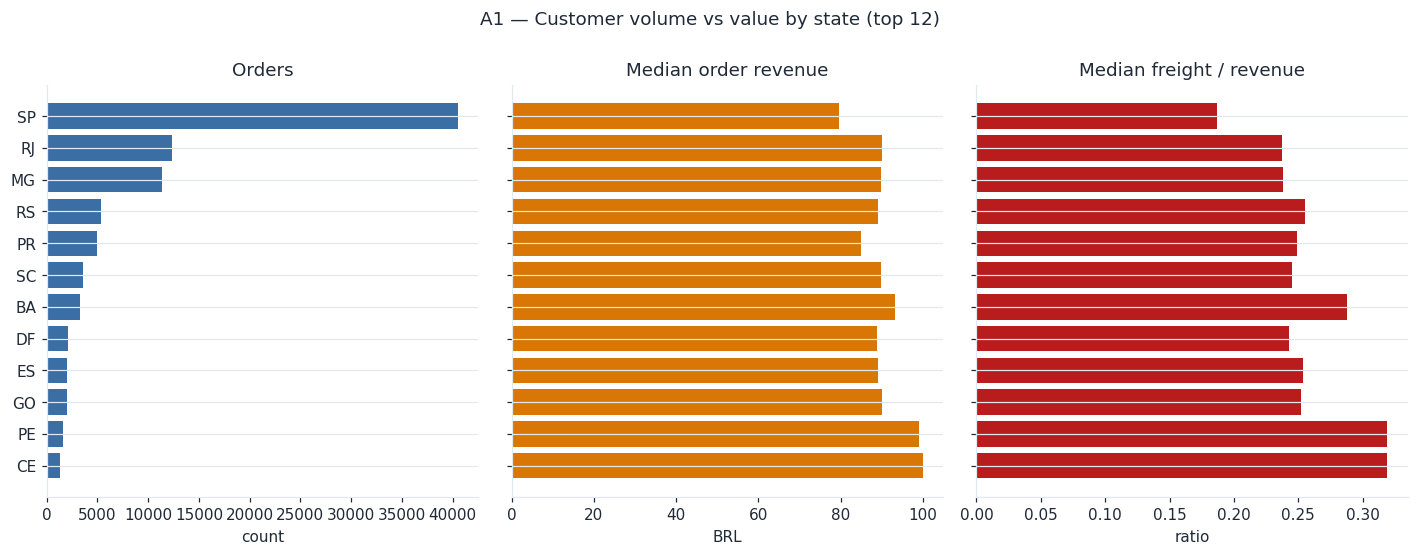

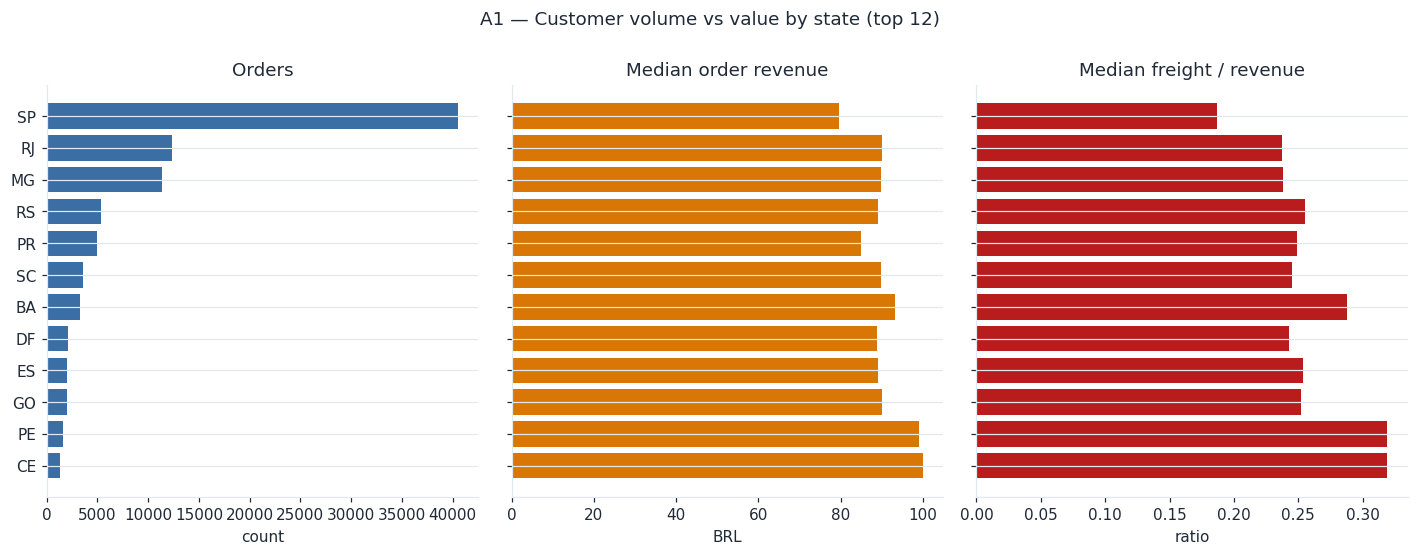

In [8]:
df = order_frame[order_frame["is_fulfilled"] & order_frame["revenue"].notna()]

state_stats = (
    df.groupby("customer_state", observed=True)
    .agg(
        orders=("order_id", "count"),
        median_revenue=("revenue", "median"),
        median_freight_ratio=("freight_ratio", "median"),
        median_delivery_days=("delivery_days", "median"),
    )
    .sort_values("orders", ascending=False)
)

top = state_stats.head(12).iloc[::-1]   # reverse: largest ends up on top
y = np.arange(len(top))

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
axes[0].barh(y, top["orders"], color=PALETTE[0])
axes[0].set_yticks(y, top.index)
axes[0].set_title("Orders"); axes[0].set_xlabel("count")

axes[1].barh(y, top["median_revenue"], color=PALETTE[1])
axes[1].set_title("Median order revenue"); axes[1].set_xlabel("BRL")

axes[2].barh(y, top["median_freight_ratio"], color=PALETTE[3])
axes[2].set_title("Median freight / revenue"); axes[2].set_xlabel("ratio")

fig.suptitle("A1 — Customer volume vs value by state (top 12)", y=1.00)
fig.tight_layout()

display(state_stats.head(10).round(3))
show(fig, "a1_geography")

## A2. How concentrated is revenue across customers?

**Why it matters:** this decides whether targeted retention is worth doing at
all. If the top decile drives a large revenue share, VIP treatment pays. If
revenue is flat across customers, only acquisition matters.

**Chart:** Lorenz curve with Gini. A histogram shows spread; a Lorenz curve
answers "how unequal" on one axis against an explicit equality reference.

Gini                     0.5208
top 10% revenue share    0.4113
top 20% revenue share    0.5667


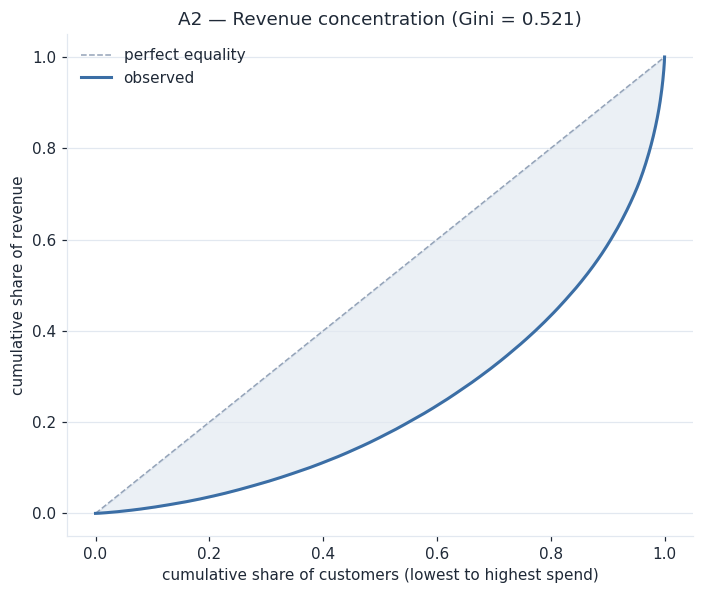

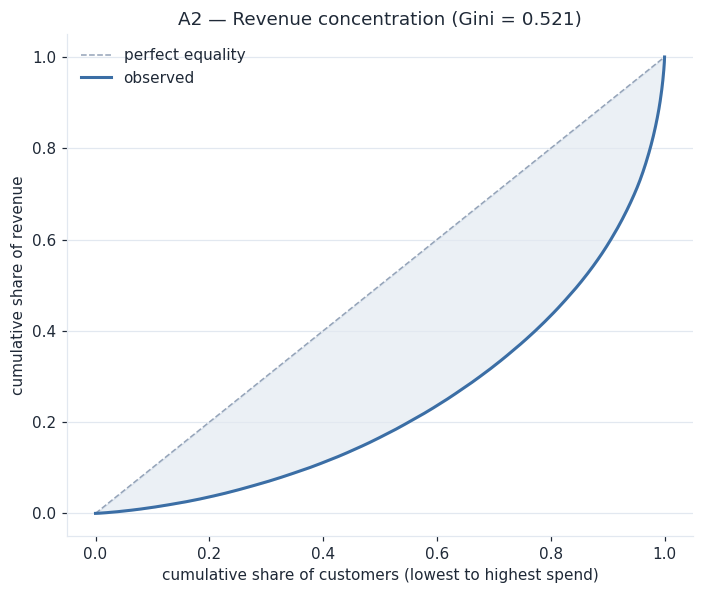

In [9]:
def gini(values):
    """0 = perfectly equal, 1 = one customer holds everything.

    Uses the sorted-cumulative formula rather than pairwise differences, which
    would be O(n^2) and unusable at 95k rows.
    """
    x = np.sort(np.asarray(values, dtype=float))
    n = x.size
    if n == 0 or x.sum() == 0:
        return float("nan")
    idx = np.arange(1, n + 1)
    return float((2 * idx - n - 1).dot(x) / (n * x.sum()))


rev = customer_frame["total_revenue"].dropna()
rev = rev[rev > 0].sort_values().to_numpy()

cum_share = np.cumsum(rev) / rev.sum()
pop_share = np.arange(1, rev.size + 1) / rev.size
g = gini(rev)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot([0, 1], [0, 1], "--", color="#94A3B8", lw=1, label="perfect equality")
ax.plot(pop_share, cum_share, color=PALETTE[0], lw=2, label="observed")
ax.fill_between(pop_share, cum_share, pop_share, color=PALETTE[0], alpha=0.10)
ax.set_xlabel("cumulative share of customers (lowest to highest spend)")
ax.set_ylabel("cumulative share of revenue")
ax.set_title(f"A2 — Revenue concentration (Gini = {g:.3f})")
ax.legend(loc="upper left")
fig.tight_layout()

print(f"Gini                     {g:.4f}")
print(f"top 10% revenue share    {1 - np.interp(0.90, pop_share, cum_share):.4f}")
print(f"top 20% revenue share    {1 - np.interp(0.80, pop_share, cum_share):.4f}")
show(fig, "a2_revenue_concentration")

## A3. When do people buy?

**Why it matters:** sets campaign send times and support staffing.

**Chart:** heatmap. You are looking at the *interaction* of two cyclical
variables; two separate bar charts would hide it.

purchase_dow  purchase_hour
1             14               1106
0             21               1103
              14               1082
              16               1076
1             16               1074
dtype: int64

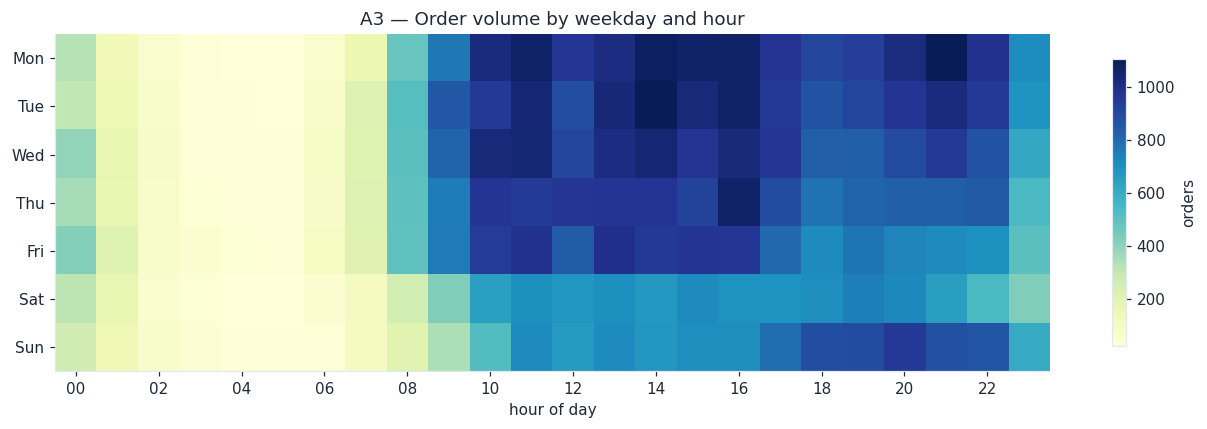

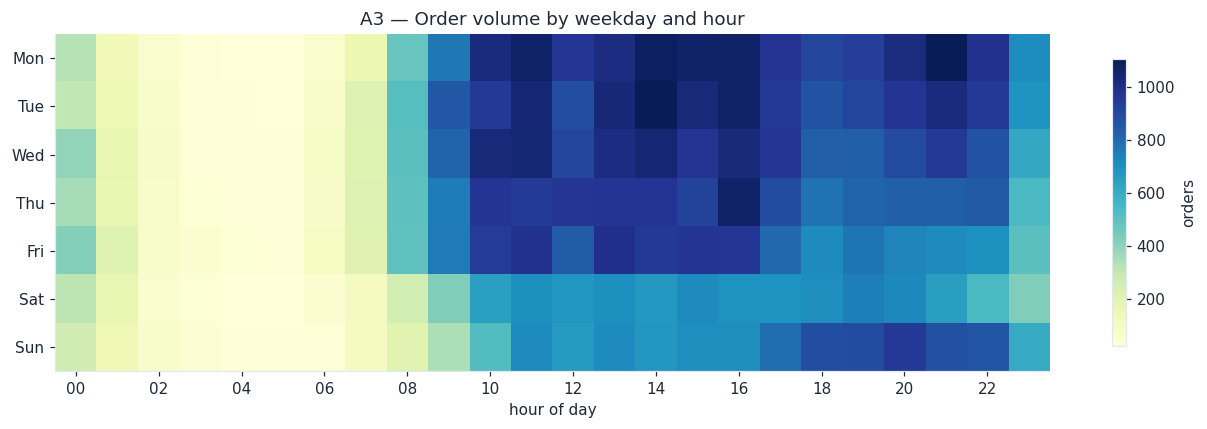

In [10]:
active_orders = order_frame[order_frame["is_active"]]

pivot = (
    active_orders.pivot_table(
        index="purchase_dow", columns="purchase_hour",
        values="order_id", aggfunc="count",
    )
    .reindex(index=range(7), columns=range(24))
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.to_numpy(), aspect="auto", cmap="YlGnBu")
ax.set_yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
ax.set_xlabel("hour of day")
ax.set_title("A3 — Order volume by weekday and hour")
ax.grid(False)
fig.colorbar(im, ax=ax, label="orders", shrink=0.85)
fig.tight_layout()

# .stack() flattens the 7x24 matrix into a ranked list of cells -- cleaner
# than nested argmax calls.
display(pivot.stack().sort_values(ascending=False).head(5))
show(fig, "a3_purchase_timing")

---
# Section B — Sales and revenue

## B4. Where does gross order value leak before it becomes net revenue?

**Why it matters:** order value is not revenue. Cancellations, unavailable
items and freight all sit in between, and confusing them invalidates every
downstream number.

**Chart:** waterfall, because the point is *subtraction*. Side-by-side bars do
not communicate "this minus this".

,label,delta,share_of_gross
0,Gross order value,15843553.24,1.0000
1,Failed orders,-108026.21,0.0068
2,Freight (pass-through),-2241126.29,0.1415
3,Net product revenue,13494400.74,0.8517


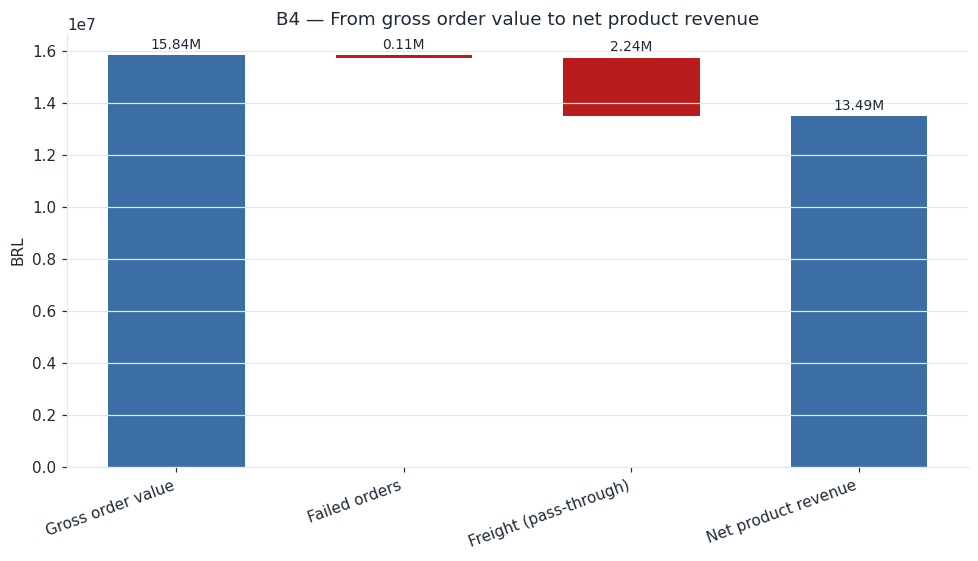

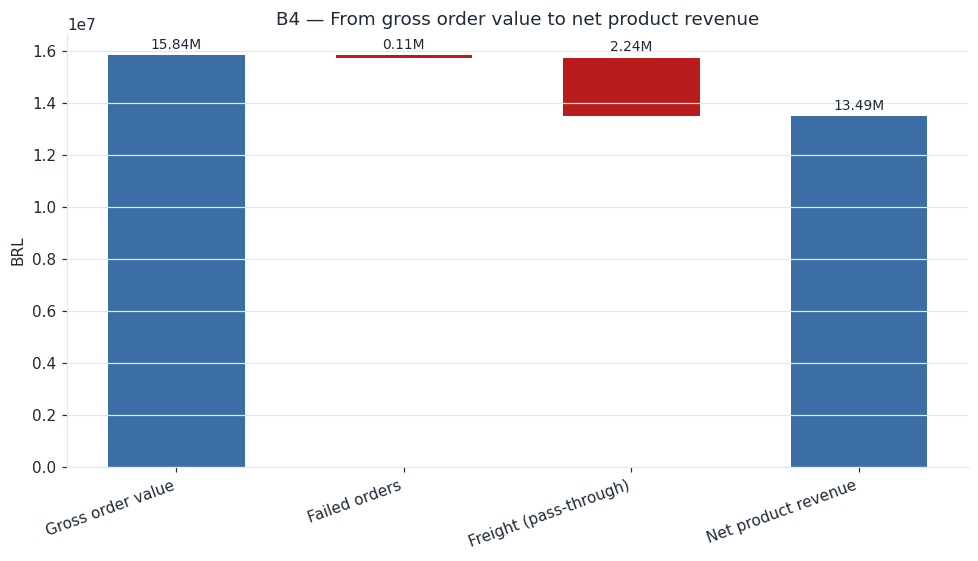

In [11]:
has_items = order_frame[order_frame["revenue"].notna()]

gross = has_items["revenue"].sum() + has_items["freight"].sum()
failed = has_items.loc[~has_items["is_active"], ["revenue", "freight"]].sum().sum()
active_o = has_items[has_items["is_active"]]
freight = active_o["freight"].sum()
net = active_o["revenue"].sum()

labels = ["Gross order value", "Failed orders", "Freight (pass-through)",
          "Net product revenue"]
deltas = [gross, -failed, -freight, net]
kinds = ["total", "down", "down", "total"]

fig, ax = plt.subplots(figsize=(9, 5.2))
running = 0.0
for i, (label, delta, kind) in enumerate(zip(labels, deltas, kinds)):
    if kind == "total":
        bottom, height, colour = 0.0, delta, PALETTE[0]
        running = delta
    else:
        # A decrease is drawn floating: its base is where the running total
        # ends up, and it rises back to where the total was.
        bottom = running + delta
        height = -delta
        colour = PALETTE[3]
        running += delta
    ax.bar(i, height, bottom=bottom, color=colour, width=0.6)
    ax.text(i, bottom + height + gross * 0.015, f"{abs(delta) / 1e6:.2f}M",
            ha="center", fontsize=9)

ax.set_xticks(range(4), labels, rotation=20, ha="right")
ax.set_ylabel("BRL")
ax.set_title("B4 — From gross order value to net product revenue")
fig.tight_layout()

waterfall = pd.DataFrame({"label": labels, "delta": deltas})
waterfall["share_of_gross"] = (waterfall["delta"].abs() / gross).round(4)
display(waterfall)
show(fig, "b4_revenue_waterfall")

## B5. What does the order-value distribution imply for pricing?

**Why it matters:** free-shipping thresholds and bundling depend on where the
mass of orders sits relative to freight cost.

**Chart:** histogram on a **log** x-axis. E-commerce order values are heavily
right-skewed; a linear histogram compresses 95% of the data into two bins.

median revenue                 86.90
mean revenue                  137.42
median freight                 17.19
share below 3x freight        30.32%
share freight > 30% value     35.10%


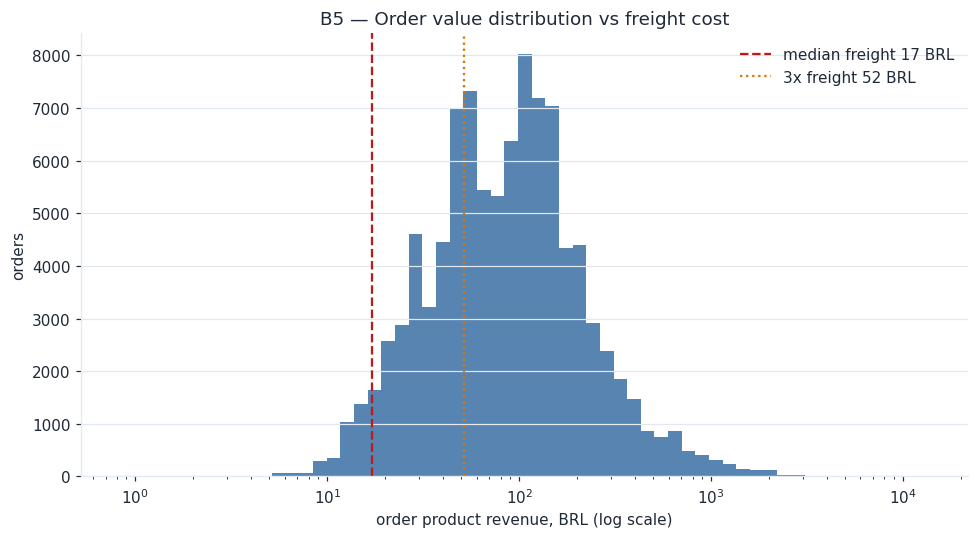

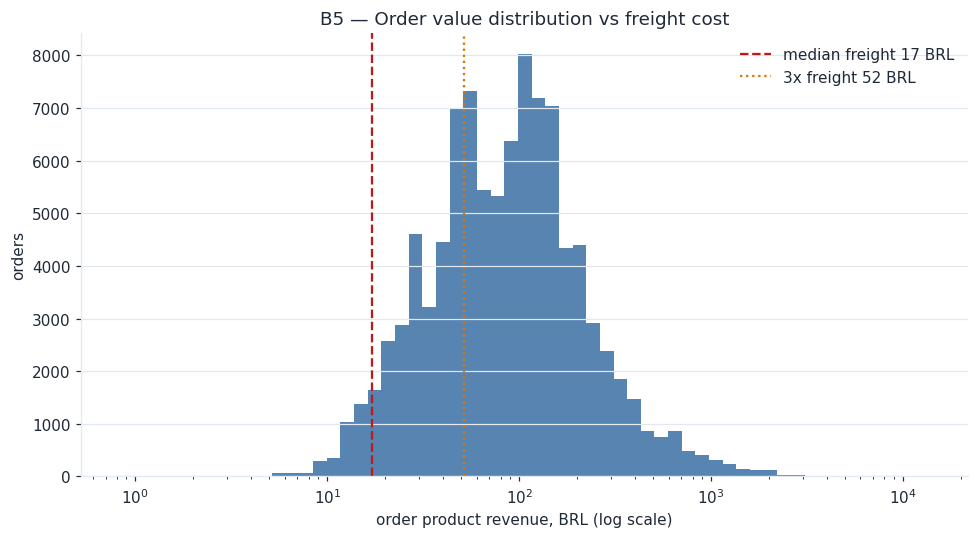

In [12]:
d = order_frame[order_frame["is_active"] & order_frame["revenue"].gt(0)]
revenue = d["revenue"]
med_freight = d["freight"].median()

fig, ax = plt.subplots(figsize=(9, 5))
# Log-spaced bin edges, so bins are equal-width *on the log scale*.
bins = np.logspace(np.log10(revenue.min()), np.log10(revenue.max()), 60)
ax.hist(revenue, bins=bins, color=PALETTE[0], alpha=0.85)
ax.set_xscale("log")
ax.axvline(med_freight, color=PALETTE[3], ls="--", lw=1.5,
           label=f"median freight {med_freight:.0f} BRL")
ax.axvline(med_freight * 3, color=PALETTE[1], ls=":", lw=1.5,
           label=f"3x freight {med_freight * 3:.0f} BRL")
ax.set_xlabel("order product revenue, BRL (log scale)")
ax.set_ylabel("orders")
ax.set_title("B5 — Order value distribution vs freight cost")
ax.legend()
fig.tight_layout()

print(f"median revenue            {revenue.median():>10,.2f}")
print(f"mean revenue              {revenue.mean():>10,.2f}")
print(f"median freight            {med_freight:>10,.2f}")
print(f"share below 3x freight    {(revenue < med_freight * 3).mean():>10.2%}")
print(f"share freight > 30% value {d['freight_ratio'].gt(0.30).mean():>10.2%}")
show(fig, "b5_order_value_distribution")

## B6. Do split and multi-item orders behave differently?

**Why it matters:** if split orders underperform, that is a fixable problem in
how Olist splits fulfilment.

**Watch carefully:** the two metrics here disagree in a way that reveals a data
problem. Note it before reading the numbers.

,orders,late_rate,mean_review,median_delivery_days
1 seller,95203,0.0820,4.1731,10.2517
2+ sellers,1275,0.0141,2.8588,7.9277
1 item,86843,0.0829,4.2134,10.2612
2+ items,9635,0.0653,3.6341,9.9124


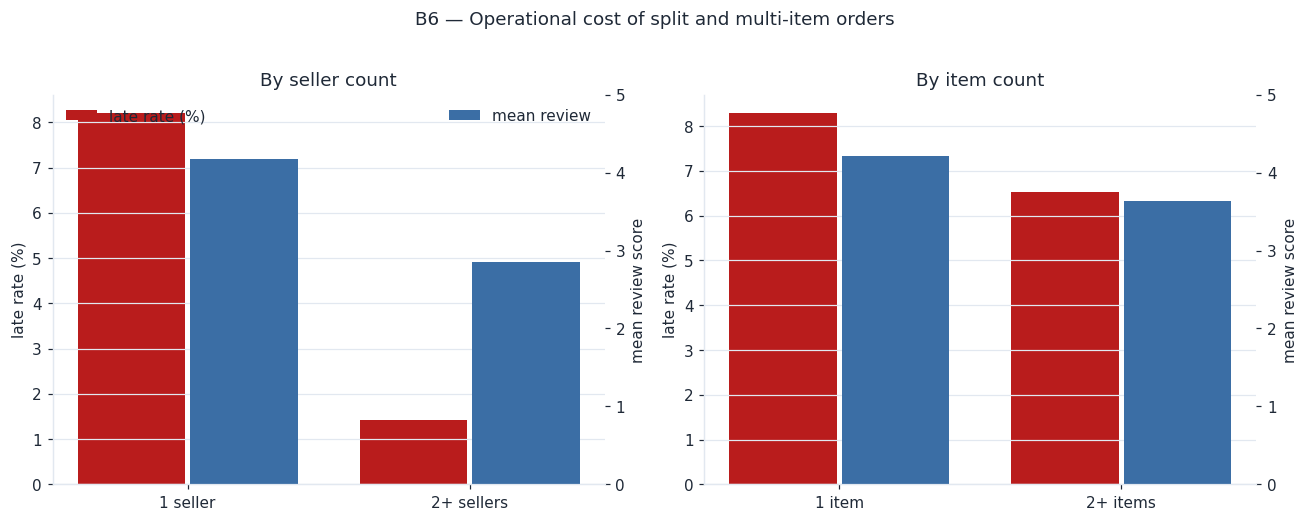

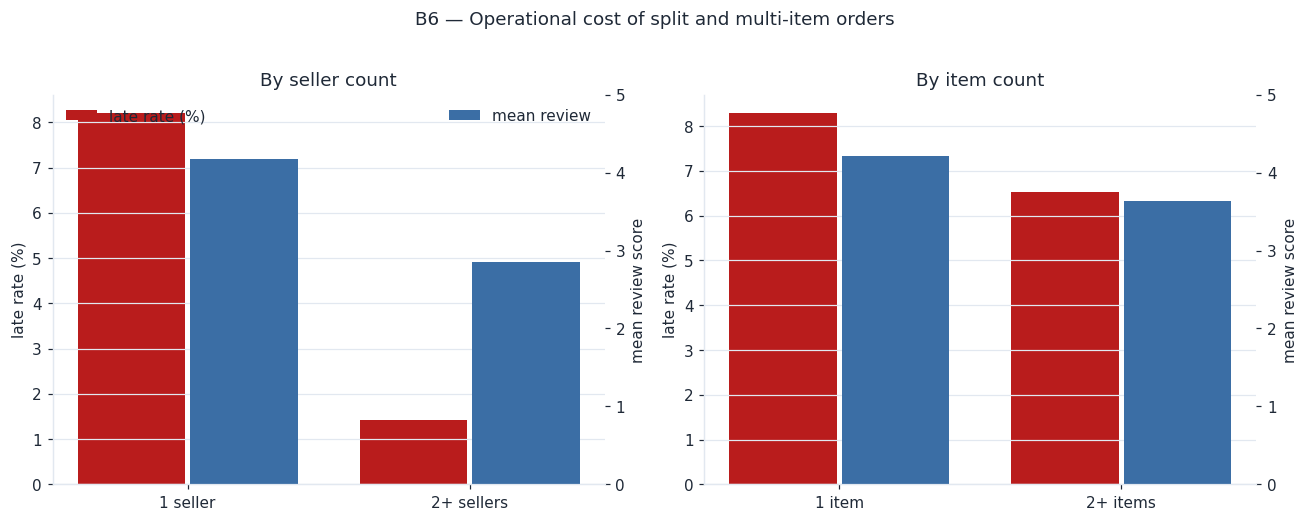

In [13]:
d = order_frame[order_frame["is_fulfilled"] & order_frame["n_sellers"].notna()].copy()
d["seller_group"] = np.where(d["n_sellers"] > 1, "2+ sellers", "1 seller")
d["item_group"] = np.where(d["n_items"] > 1, "2+ items", "1 item")

def summarise(col):
    return d.groupby(col, observed=True).agg(
        orders=("order_id", "count"),
        late_rate=("is_late", "mean"),
        mean_review=("review_score", "mean"),
        median_delivery_days=("delivery_days", "median"),
    )

by_seller, by_item = summarise("seller_group"), summarise("item_group")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, tbl, title in [(axes[0], by_seller, "By seller count"),
                       (axes[1], by_item, "By item count")]:
    x = np.arange(len(tbl))
    ax.bar(x - 0.2, tbl["late_rate"] * 100, width=0.38, color=PALETTE[3],
           label="late rate (%)")
    ax2 = ax.twinx()   # two incomparable units, so two axes
    ax2.bar(x + 0.2, tbl["mean_review"], width=0.38, color=PALETTE[0],
            label="mean review")
    ax2.set_ylim(0, 5); ax2.grid(False)
    ax.set_xticks(x, tbl.index)
    ax.set_ylabel("late rate (%)"); ax2.set_ylabel("mean review score")
    ax.set_title(title)
    if ax is axes[0]:
        ax.legend(loc="upper left"); ax2.legend(loc="upper right")

fig.suptitle("B6 — Operational cost of split and multi-item orders", y=1.02)
fig.tight_layout()

display(pd.concat([by_seller, by_item]).round(4))
show(fig, "b6_multi_seller_effects")

**Read that table again.** Split orders are late *less* often (1.4% vs 8.2%)
yet score 1.3 stars worse (2.86 vs 4.17). A better late rate cannot produce
much worse satisfaction — so `order_delivered_customer_date` almost certainly
records one shipment's arrival, not the last. **Do not trust `is_late` for
multi-seller orders.** Two metrics that should have agreed did not, and that
disagreement found a data-integrity problem.

---
# Section C — Products

## C7. How concentrated are sales across the catalogue?

**Why it matters:** this determines whether the recommender needs long-tail
coverage. It is the quantitative case for content-based recommendation over
collaborative filtering.

products                          32,951
catalogue share for 50% of sales  0.0807
catalogue share for 80% of sales  0.3832
products sold exactly once        18,117 (55.0%)


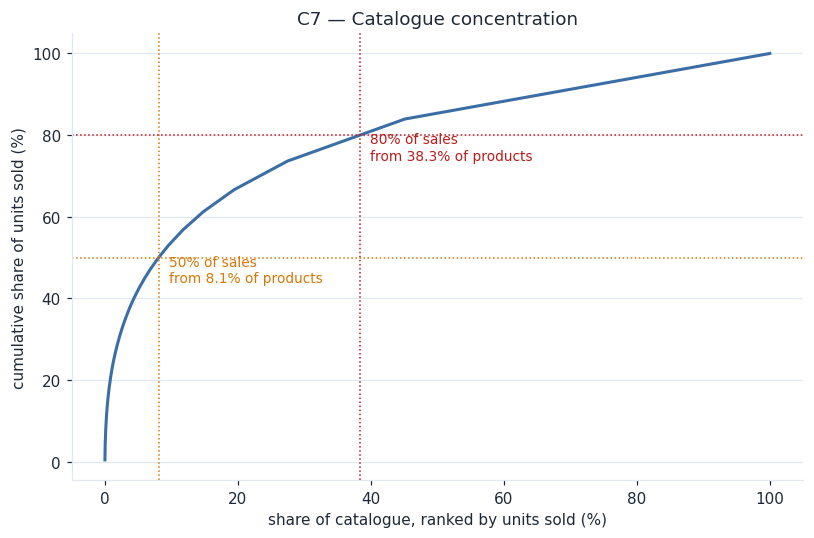

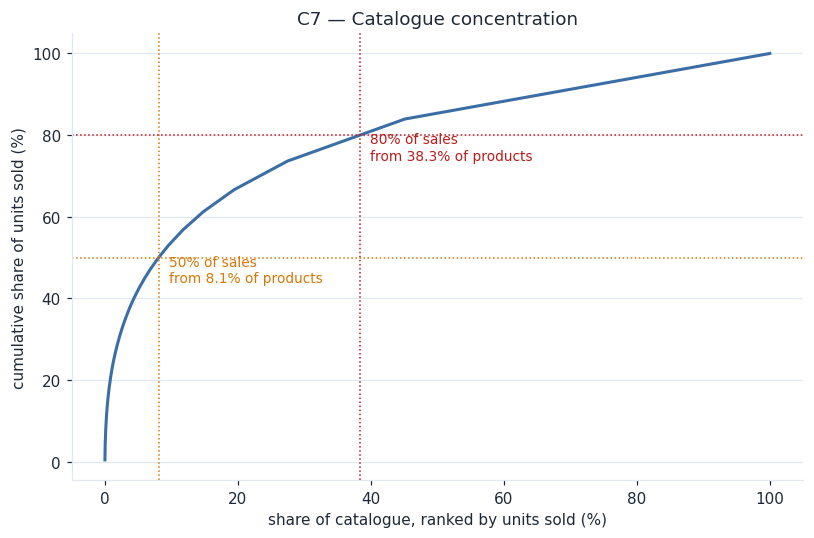

In [14]:
counts = tables["order_items"]["product_id"].value_counts().to_numpy()
cum = np.cumsum(counts) / counts.sum()
rank_share = np.arange(1, counts.size + 1) / counts.size

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(rank_share * 100, cum * 100, color=PALETTE[0], lw=2)
for share, colour, lab in [(0.50, PALETTE[1], "50%"), (0.80, PALETTE[3], "80%")]:
    # np.interp inverts the curve: given a sales share, what catalogue share?
    x = np.interp(share, cum, rank_share) * 100
    ax.axhline(share * 100, color=colour, ls=":", lw=1)
    ax.axvline(x, color=colour, ls=":", lw=1)
    ax.text(x + 1.5, share * 100 - 6,
            f"{lab} of sales\nfrom {x:.1f}% of products", fontsize=9, color=colour)
ax.set_xlabel("share of catalogue, ranked by units sold (%)")
ax.set_ylabel("cumulative share of units sold (%)")
ax.set_title("C7 — Catalogue concentration")
fig.tight_layout()

print(f"products                          {counts.size:,}")
print(f"catalogue share for 50% of sales  {np.interp(0.50, cum, rank_share):.4f}")
print(f"catalogue share for 80% of sales  {np.interp(0.80, cum, rank_share):.4f}")
print(f"products sold exactly once        {(counts == 1).sum():,} "
      f"({(counts == 1).mean():.1%})")
show(fig, "c7_catalogue_pareto")

## C8. Does size drive freight, and does freight burden drive dissatisfaction?

**Chart:** log-log scatter, because both variables span four orders of
magnitude and the relationship is multiplicative. Correlating the **logs** is
the right measure; raw Pearson would be dragged around by a few 30kg items.

,mean_review,n
freight_ratio,,
"(-0.001, 0.0884]",4.206,12062
"(0.0884, 0.132]",4.196,12058
"(0.132, 0.174]",4.175,12059
"(0.174, 0.224]",4.154,12085
"(0.224, 0.288]",4.167,12037
"(0.288, 0.381]",4.122,12058
"(0.381, 0.563]",4.123,12059
"(0.563, 21.447]",4.104,12060


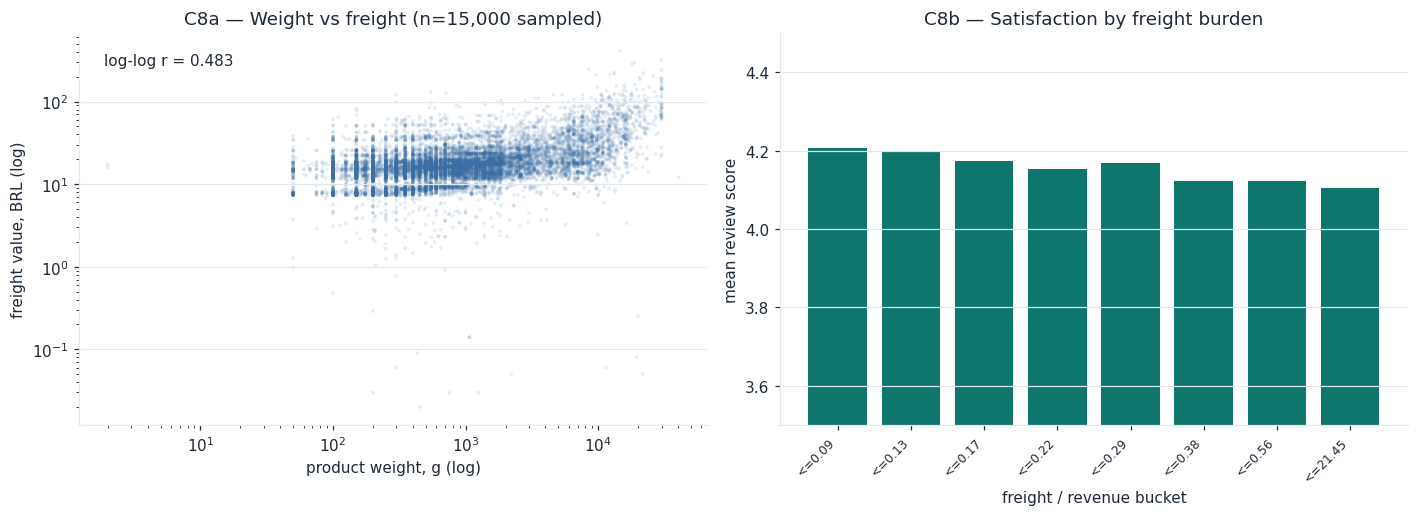

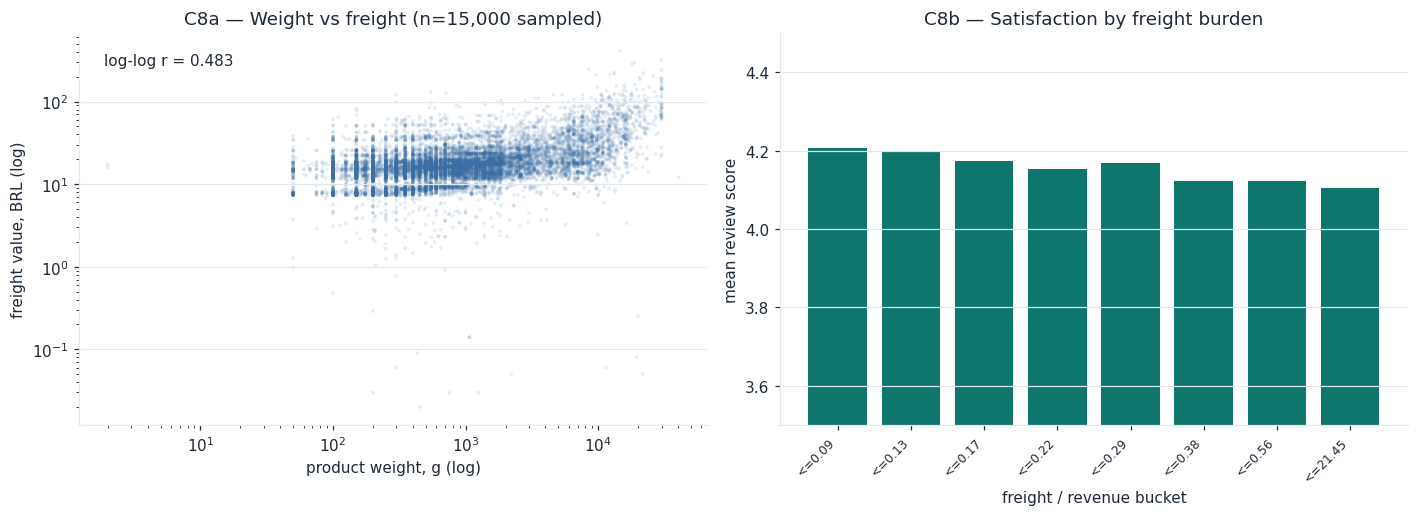

In [15]:
items = tables["order_items"].merge(
    tables["products"][["product_id", "product_weight_g"]], on="product_id", how="left"
)
items = items[items["product_weight_g"].gt(0) & items["freight_value"].gt(0)]
s = items.sample(min(15000, len(items)), random_state=42)   # 112k points is mush

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(s["product_weight_g"], s["freight_value"], s=6, alpha=0.12,
                color=PALETTE[0], edgecolors="none")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("product weight, g (log)")
axes[0].set_ylabel("freight value, BRL (log)")
axes[0].set_title(f"C8a — Weight vs freight (n={len(s):,} sampled)")
corr = np.corrcoef(np.log10(items["product_weight_g"]),
                   np.log10(items["freight_value"]))[0, 1]
axes[0].text(0.04, 0.92, f"log-log r = {corr:.3f}", transform=axes[0].transAxes)

d = order_frame[order_frame["is_fulfilled"] & order_frame["freight_ratio"].notna()]
buckets = pd.qcut(d["freight_ratio"], q=8, duplicates="drop")
freight_tbl = d.groupby(buckets, observed=True).agg(
    mean_review=("review_score", "mean"), n=("order_id", "count")
)
axes[1].bar(range(len(freight_tbl)), freight_tbl["mean_review"], color=PALETTE[2])
axes[1].set_xticks(range(len(freight_tbl)),
                   [f"<={iv.right:.2f}" for iv in freight_tbl.index],
                   rotation=45, ha="right", fontsize=8)
axes[1].set_ylim(3.5, 4.5)   # zoomed: the whole effect is ~0.1 stars
axes[1].set_ylabel("mean review score")
axes[1].set_xlabel("freight / revenue bucket")
axes[1].set_title("C8b — Satisfaction by freight burden")
fig.tight_layout()

display(freight_tbl.round(3))
show(fig, "c8_size_freight_satisfaction")

## C9. Which products get systematically bad reviews at real volume?

**Why it matters:** delisting or renegotiating a handful of products may be the
cheapest satisfaction win available. Volume matters — a 1.0 average from two
sales is noise, not a signal.

,orders,mean_review,revenue
product_id,,,
b5e13c9a353102f79c6206ff5cb61a50,83,2.95,7890.79
89b121bee266dcd25688a1ba72eefb61,62,2.28,5452.10
b1d207586fca400a2370d50a9ba1da98,43,2.02,7152.00
9ad75bd7267e5c724cb42c71ac56ca72,42,2.93,6045.30
25c38557cf793876c5abdd5931f922db,38,2.68,39117.31
1dec4c88c685d5a07bf01dcb0f8bf9f8,35,2.74,19965.00
0cf41187284d7f099adc8415a743ebbd,33,2.76,1915.29
cd46a885543f0e169a49f1eb25c04e43,28,1.61,2999.70
fb01a5fc09b9b9563c2ee41a22f07d54,24,2.87,16731.79


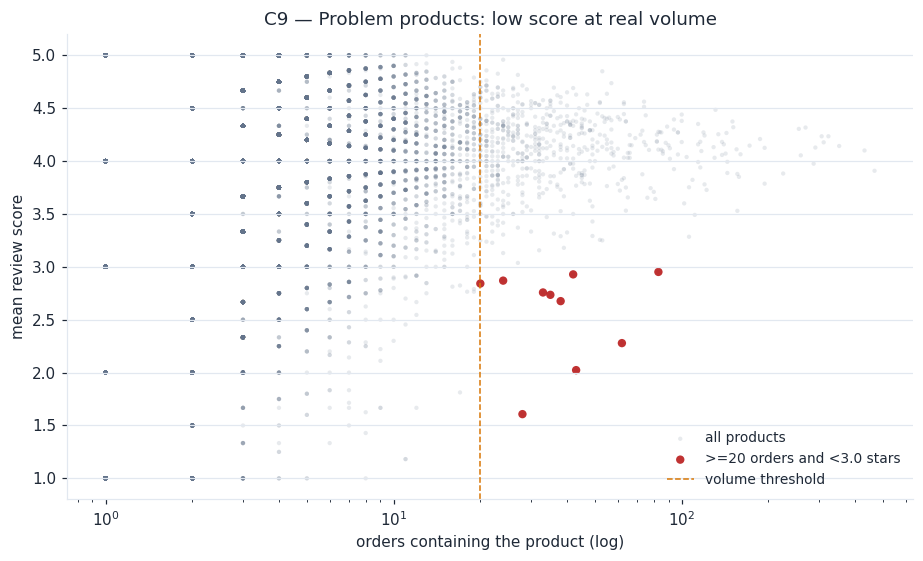

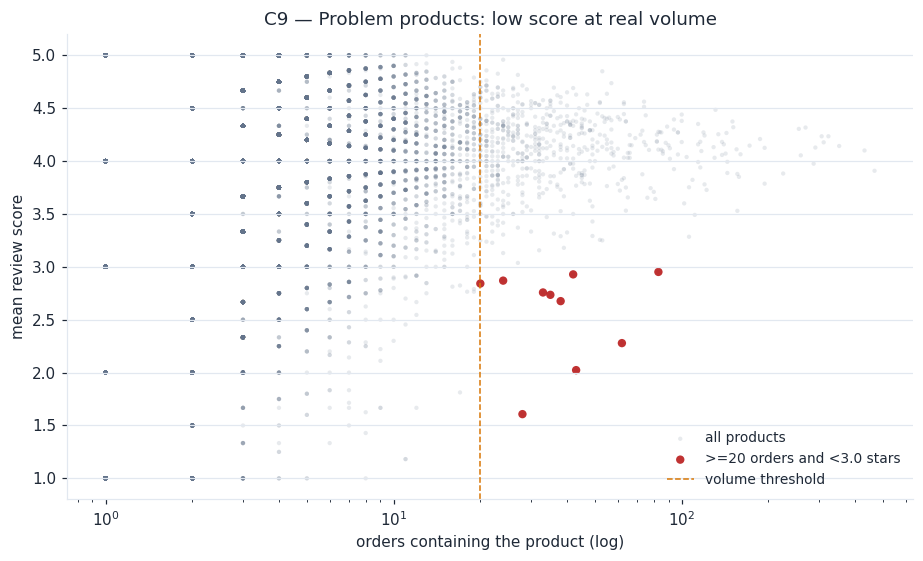

In [16]:
MIN_ORDERS = 20

link = tables["order_items"][["order_id", "product_id"]].drop_duplicates()
joined = link.merge(order_frame[["order_id", "review_score", "revenue"]],
                    on="order_id", how="left")
prod = (
    joined.groupby("product_id")
    .agg(orders=("order_id", "nunique"),
         mean_review=("review_score", "mean"),
         revenue=("revenue", "sum"))
    .dropna(subset=["mean_review"])
)

eligible = prod[prod["orders"] >= MIN_ORDERS]
problem = eligible[eligible["mean_review"] < 3.0].sort_values("orders", ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.scatter(prod["orders"], prod["mean_review"], s=8, alpha=0.15,
           color=PALETTE[5], edgecolors="none", label="all products")
ax.scatter(problem["orders"], problem["mean_review"], s=30, alpha=0.9,
           color=PALETTE[3], edgecolors="none",
           label=f">={MIN_ORDERS} orders and <3.0 stars")
ax.axvline(MIN_ORDERS, color=PALETTE[1], ls="--", lw=1, label="volume threshold")
ax.set_xscale("log")
ax.set_xlabel("orders containing the product (log)")
ax.set_ylabel("mean review score")
ax.set_title("C9 — Problem products: low score at real volume")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()

display(problem.head(15).round(2))
show(fig, "c9_problem_products")

---
# Section D — Categories

## D10. Which categories drive revenue versus volume?

**Why it matters:** the two rankings differ, and marketing and inventory need
different answers.

,orders,revenue,median_order_value,revenue_share
category,,,,
health_beauty,8613,1233813.10,86.00,0.095
watches_gifts,5478,1167152.18,139.90,0.089
bed_bath_table,9184,1024243.76,89.00,0.078
sports_leisure,7493,954525.89,89.90,0.073
computers_accessories,6512,888593.98,86.60,0.068
furniture_decor,6188,709574.80,79.90,0.054
housewares,5680,615325.93,69.80,0.047
cool_stuff,3530,610373.43,129.99,0.047
auto,3793,579364.15,89.99,0.044


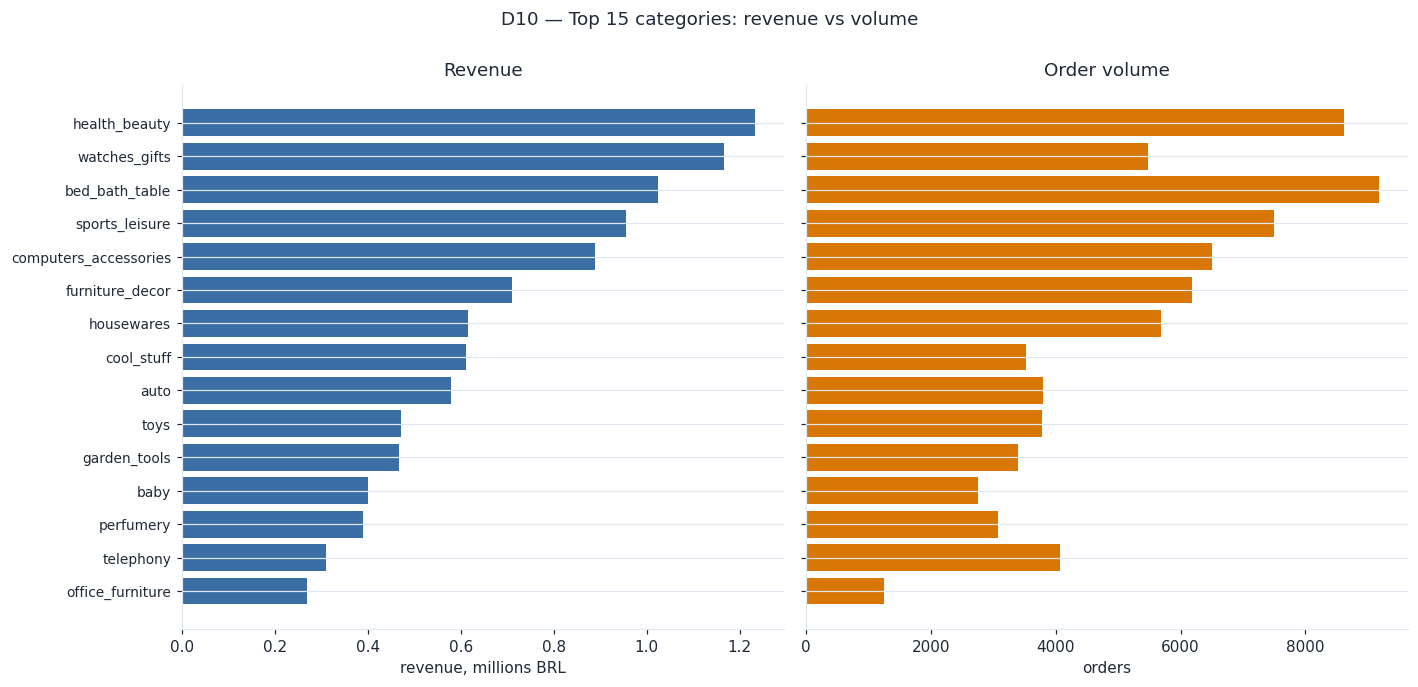

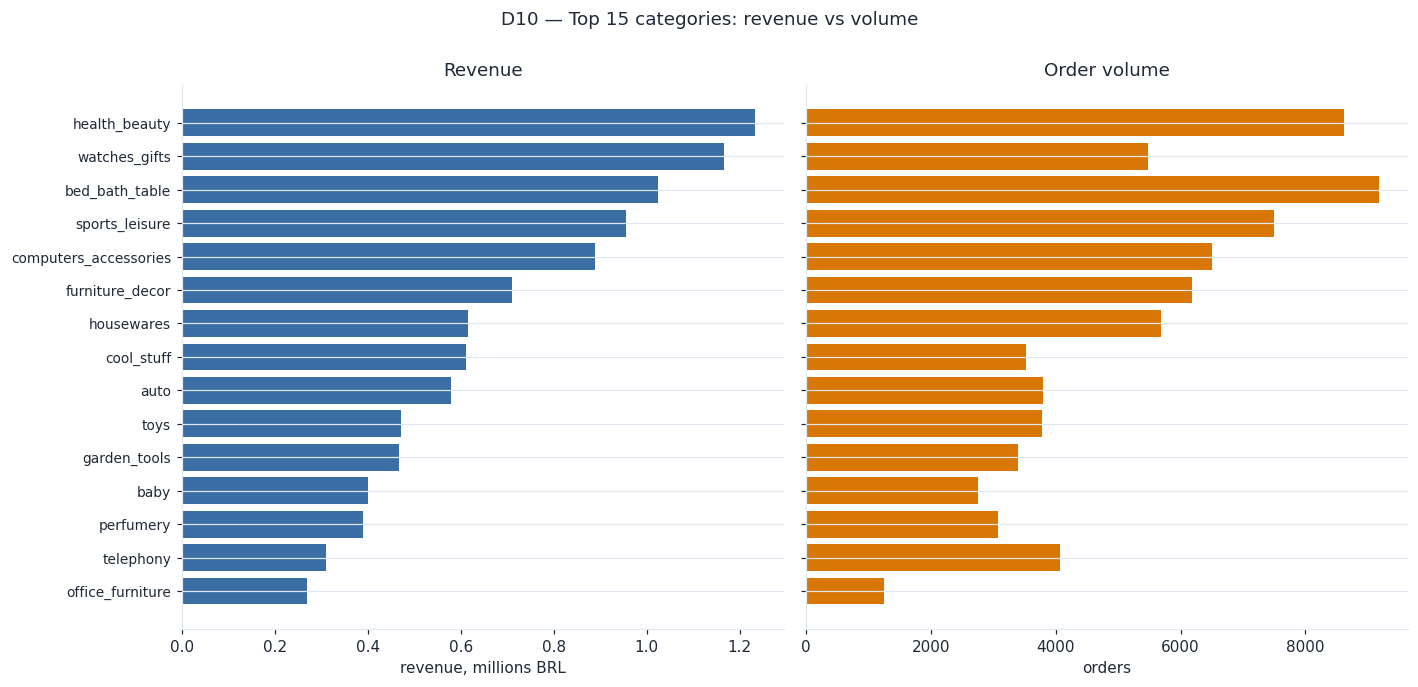

In [17]:
labels_map = category_labels(tables)

d = order_frame[order_frame["is_fulfilled"] & order_frame["primary_category"].notna()].copy()
d["category"] = d["primary_category"].map(labels_map).fillna(d["primary_category"])

cat_stats = d.groupby("category", observed=True).agg(
    orders=("order_id", "count"),
    revenue=("revenue", "sum"),
    median_order_value=("revenue", "median"),
    mean_review=("review_score", "mean"),
    late_rate=("is_late", "mean"),
    median_delivery_days=("delivery_days", "median"),
    median_freight_ratio=("freight_ratio", "median"),
)
cat_stats["revenue_share"] = cat_stats["revenue"] / cat_stats["revenue"].sum()
cat_stats = cat_stats.sort_values("revenue", ascending=False)

sub = cat_stats.head(15).iloc[::-1]
y = np.arange(len(sub))

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2), sharey=True)
axes[0].barh(y, sub["revenue"] / 1e6, color=PALETTE[0])
axes[0].set_yticks(y, sub.index, fontsize=9)
axes[0].set_xlabel("revenue, millions BRL"); axes[0].set_title("Revenue")
axes[1].barh(y, sub["orders"], color=PALETTE[1])
axes[1].set_xlabel("orders"); axes[1].set_title("Order volume")
fig.suptitle("D10 — Top 15 categories: revenue vs volume", y=1.00)
fig.tight_layout()

display(cat_stats.head(15)[["orders", "revenue", "median_order_value",
                            "revenue_share"]].round(3))
show(fig, "d10_revenue_vs_volume")

## D11. Which categories are operationally painful?

**Chart:** bubble scatter — four dimensions in one readable picture. Bubble
**area** is proportional to revenue: `s=` in matplotlib is area in points², so
passing a value directly would make the eye read differences as their square
root and understate them.

,orders,revenue_share,mean_review,late_rate,median_delivery_days
category,,,,,
watches_gifts,5478,0.0894,4.1228,0.0854,10.3551
bed_bath_table,9184,0.0785,4.0073,0.0881,10.7487
furniture_decor,6188,0.0544,4.0773,0.0861,10.9147
auto,3793,0.0444,4.1534,0.0865,9.7604
baby,2761,0.0307,4.1212,0.0927,10.0731
telephony,4073,0.0237,4.0593,0.0854,10.8150
office_furniture,1251,0.0206,3.6463,0.0919,18.8745
electronics,2502,0.0119,4.1293,0.0987,11.0234
consoles_games,1013,0.0113,4.1823,0.0819,11.3379


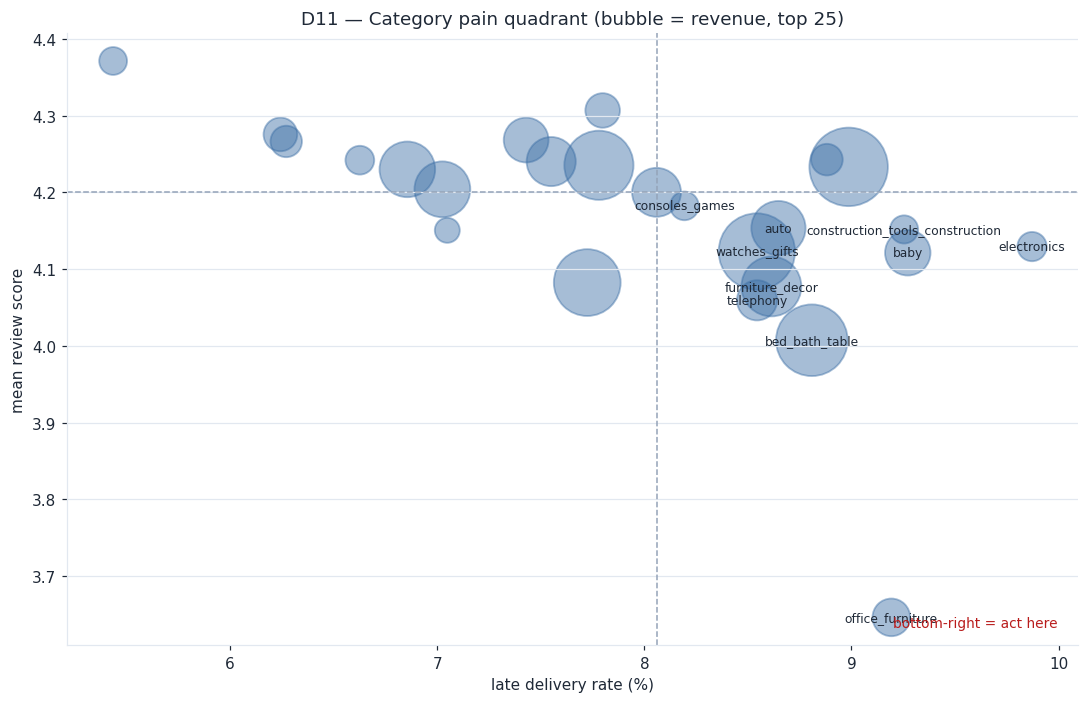

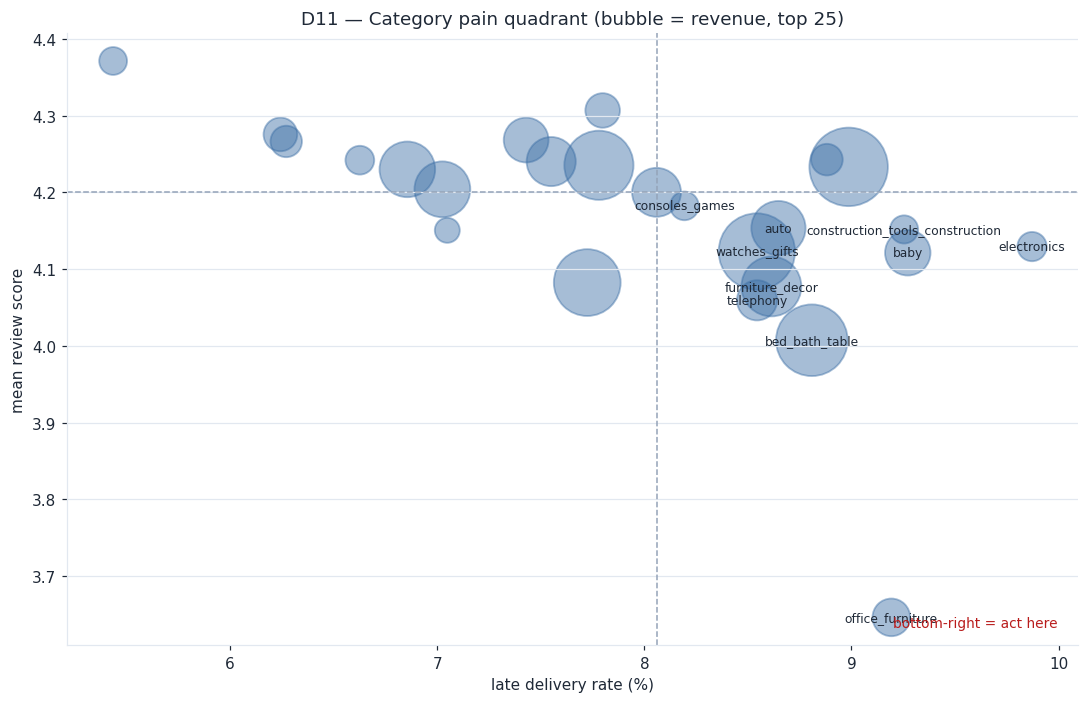

In [18]:
sub = cat_stats[cat_stats["orders"] >= 200].head(25)

fig, ax = plt.subplots(figsize=(10, 6.5))
sizes = 40 + 2600 * (sub["revenue"] / sub["revenue"].max())   # linear in AREA
ax.scatter(sub["late_rate"] * 100, sub["mean_review"], s=sizes, alpha=0.45,
           color=PALETTE[0], edgecolors=PALETTE[0], linewidths=1.2)

x_mid = sub["late_rate"].median() * 100
y_mid = sub["mean_review"].median()
ax.axvline(x_mid, color="#94A3B8", ls="--", lw=1)
ax.axhline(y_mid, color="#94A3B8", ls="--", lw=1)

# Label only the problem quadrant, or the chart becomes unreadable.
pain = sub[(sub["late_rate"] * 100 > x_mid) & (sub["mean_review"] < y_mid)]
for name, row in pain.iterrows():
    ax.annotate(name, (row["late_rate"] * 100, row["mean_review"]),
                fontsize=8, ha="center", va="center")

ax.set_xlabel("late delivery rate (%)")
ax.set_ylabel("mean review score")
ax.set_title("D11 — Category pain quadrant (bubble = revenue, top 25)")
ax.text(0.98, 0.03, "bottom-right = act here", transform=ax.transAxes,
        ha="right", fontsize=9, color=PALETTE[3])
fig.tight_layout()

display(pain.sort_values("revenue", ascending=False)[
    ["orders", "revenue_share", "mean_review", "late_rate", "median_delivery_days"]
].round(4))
show(fig, "d11_pain_quadrant")

---
# Section E — Time trends

## E12. Is the business growing, and which periods are usable?

**Why it matters:** Nov 2016 has **zero** orders and Sept–Oct 2018 has 20.
Those tails must be excluded from every later phase, and this chart is the
justification.

,revenue,orders,mom_growth
order_purchase_timestamp,,,
2016-09-01,135.0,1,NaN
2016-10-01,40325.0,265,298.0
2016-11-01,0.0,0,-1.0
2016-12-01,11.0,1,inf
2017-01-01,111798.0,750,10256.0
2017-02-01,234223.0,1653,1.0
2017-03-01,359199.0,2546,1.0
2017-04-01,340670.0,2303,-0.0
2017-05-01,489338.0,3546,0.0


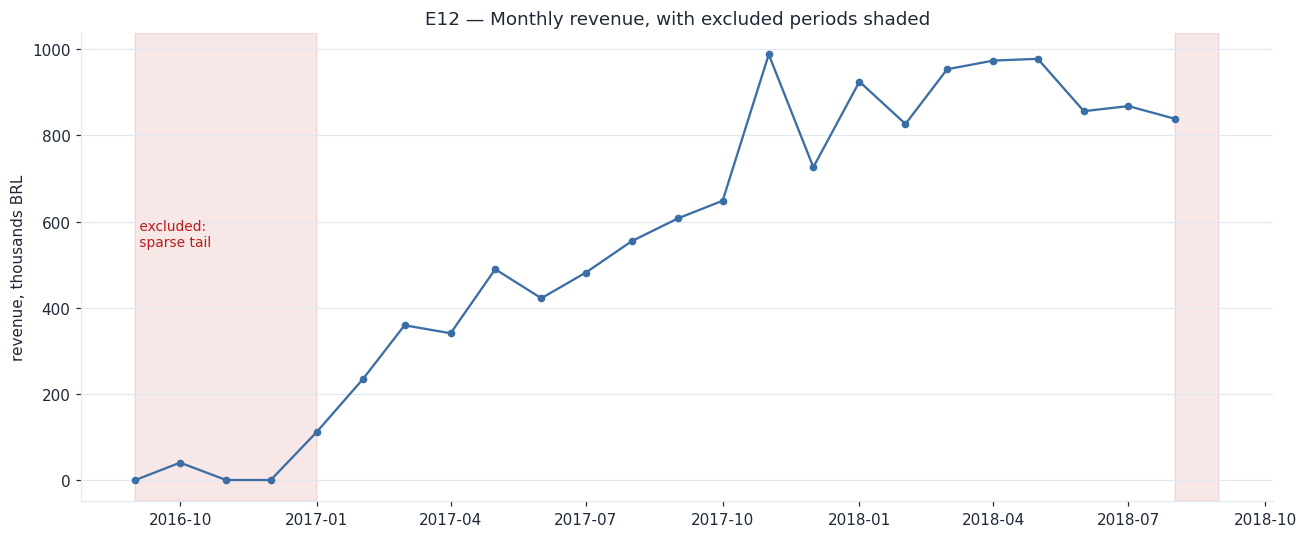

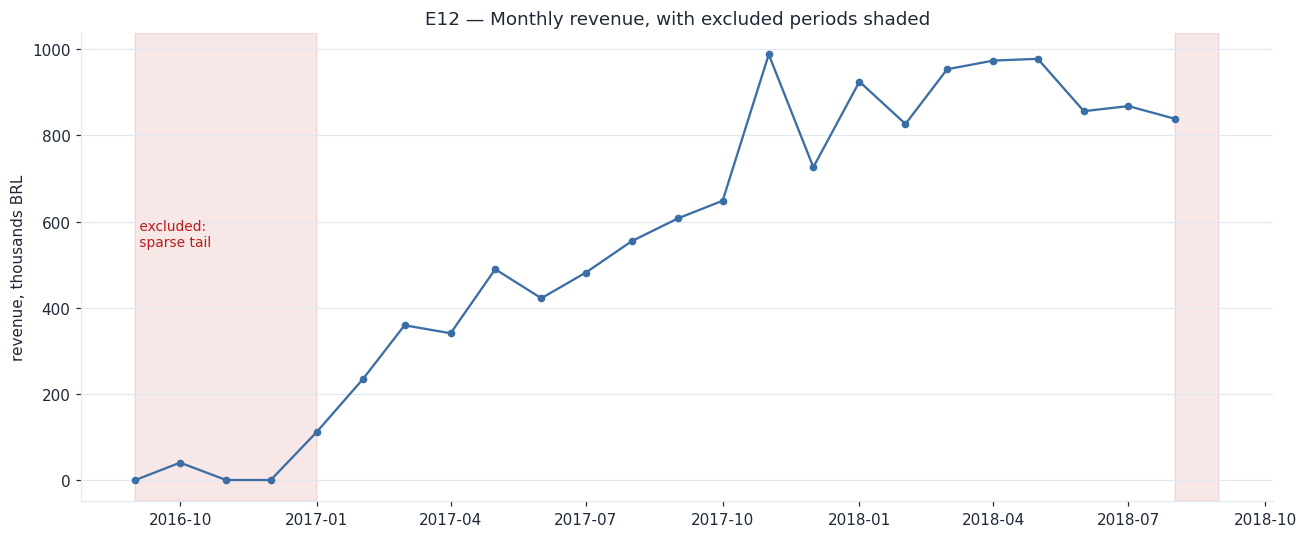

In [19]:
ANALYSIS_START = pd.Timestamp("2017-01-01")
ANALYSIS_END = pd.Timestamp("2018-08-31")

fulfilled = order_frame[order_frame["is_fulfilled"] & order_frame["revenue"].notna()]
daily_full = (
    fulfilled.set_index("order_purchase_timestamp")["revenue"]
    .resample("D").sum().asfreq("D").fillna(0.0)
)
monthly = daily_full.resample("MS").sum()
monthly_orders = (
    fulfilled.set_index("order_purchase_timestamp")["order_id"].resample("MS").count()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.index, monthly / 1e3, marker="o", ms=4, color=PALETTE[0])
ax.axvspan(monthly.index.min(), ANALYSIS_START, color=PALETTE[3], alpha=0.10)
ax.axvspan(ANALYSIS_END, monthly.index.max(), color=PALETTE[3], alpha=0.10)
ax.text(monthly.index.min(), monthly.max() / 1e3 * 0.55,
        " excluded:\n sparse tail", fontsize=9, color=PALETTE[3])
ax.set_ylabel("revenue, thousands BRL")
ax.set_title("E12 — Monthly revenue, with excluded periods shaded")
fig.tight_layout()

growth = pd.DataFrame({"revenue": monthly, "orders": monthly_orders})
growth["mom_growth"] = growth["revenue"].pct_change().round(3)
display(growth.round(0))
show(fig, "e12_growth")

## E13. What seasonality exists, and at what frequency?

**Why it matters:** you are choosing the SARIMA seasonal period here, not
decorating. Twenty months means weekly seasonality can be validated and annual
seasonality cannot — you only observe one instance of it.

days                606
zero-revenue days   4
weekday mean        23,508
weekend mean        17,337
weekend deficit     26.25%
peak day            2017-11-24  (149,917 BRL)


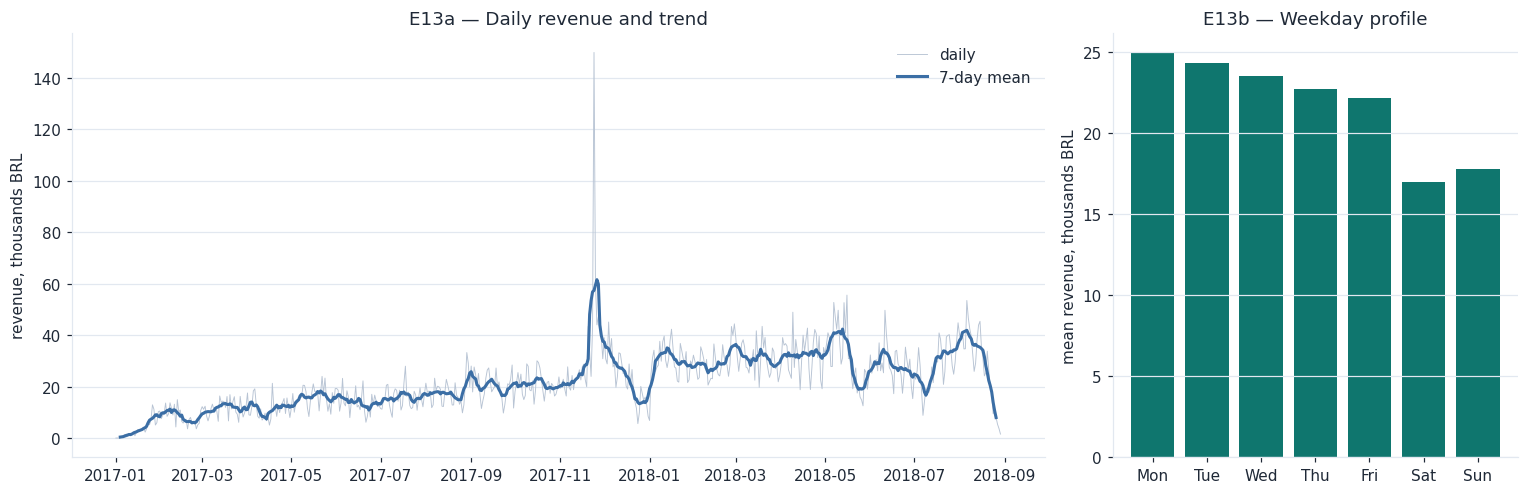

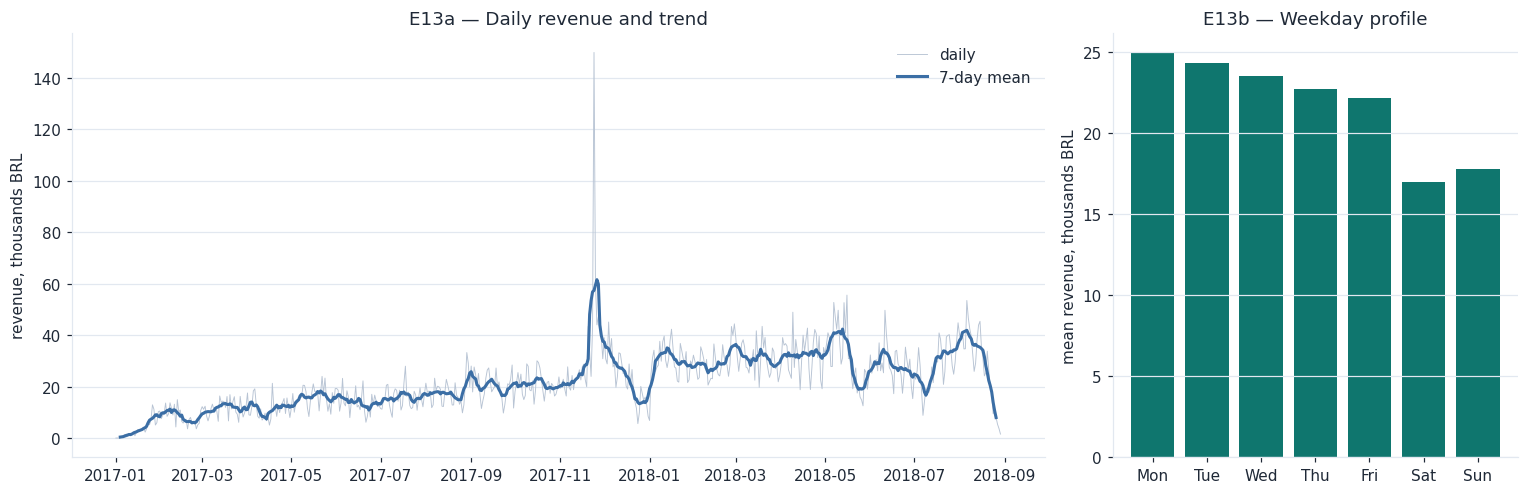

In [20]:
daily = daily_full.loc[ANALYSIS_START:ANALYSIS_END]
roll = daily.rolling(7, center=True).mean()   # centred: no lag introduced
by_dow = daily.groupby(daily.index.dayofweek).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6),
                         gridspec_kw={"width_ratios": [2.4, 1]})
axes[0].plot(daily.index, daily / 1e3, lw=0.6, color="#B8C4D4", label="daily")
axes[0].plot(roll.index, roll / 1e3, lw=2, color=PALETTE[0], label="7-day mean")
axes[0].set_ylabel("revenue, thousands BRL")
axes[0].set_title("E13a — Daily revenue and trend")
axes[0].legend()

axes[1].bar(range(7), by_dow / 1e3, color=PALETTE[2])
axes[1].set_xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_ylabel("mean revenue, thousands BRL")
axes[1].set_title("E13b — Weekday profile")
fig.tight_layout()

weekday, weekend = by_dow.loc[0:4].mean(), by_dow.loc[5:6].mean()
print(f"days                {daily.size}")
print(f"zero-revenue days   {(daily == 0).sum()}")
print(f"weekday mean        {weekday:,.0f}")
print(f"weekend mean        {weekend:,.0f}")
print(f"weekend deficit     {1 - weekend / weekday:.2%}")
print(f"peak day            {daily.idxmax().date()}  ({daily.max():,.0f} BRL)")
show(fig, "e13_seasonality")

## E14. Has delivery performance drifted over time?

**Why it matters — this is the most important confounder in the project.** If
the late rate moves a lot month to month, customers acquired in different
months had structurally different experiences. Pool them without controls and
your churn model learns a time trend and presents it as a delivery effect.

,mean_delivery_days,late_rate,mean_review,orders
order_purchase_timestamp,,,,
2017-01-01,12.6470,0.0307,4.1984,750
2017-02-01,13.1688,0.0321,4.2033,1653
2017-03-01,12.9512,0.0558,4.1868,2546
2017-04-01,14.9179,0.0786,4.1367,2303
2017-05-01,11.3224,0.0361,4.2357,3545
2017-06-01,12.0116,0.0386,4.2224,3135
2017-07-01,11.5927,0.0343,4.2582,3872
2017-08-01,11.1471,0.0332,4.3119,4193
2017-09-01,11.8510,0.0520,4.2676,4150



late rate range: 1.36% to 21.36%


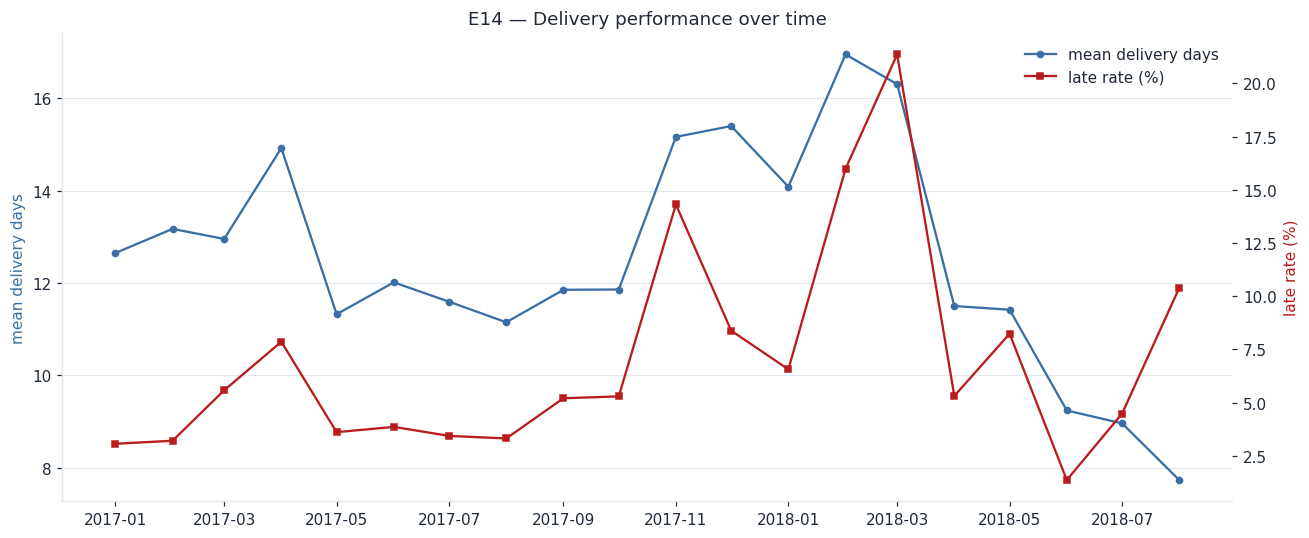

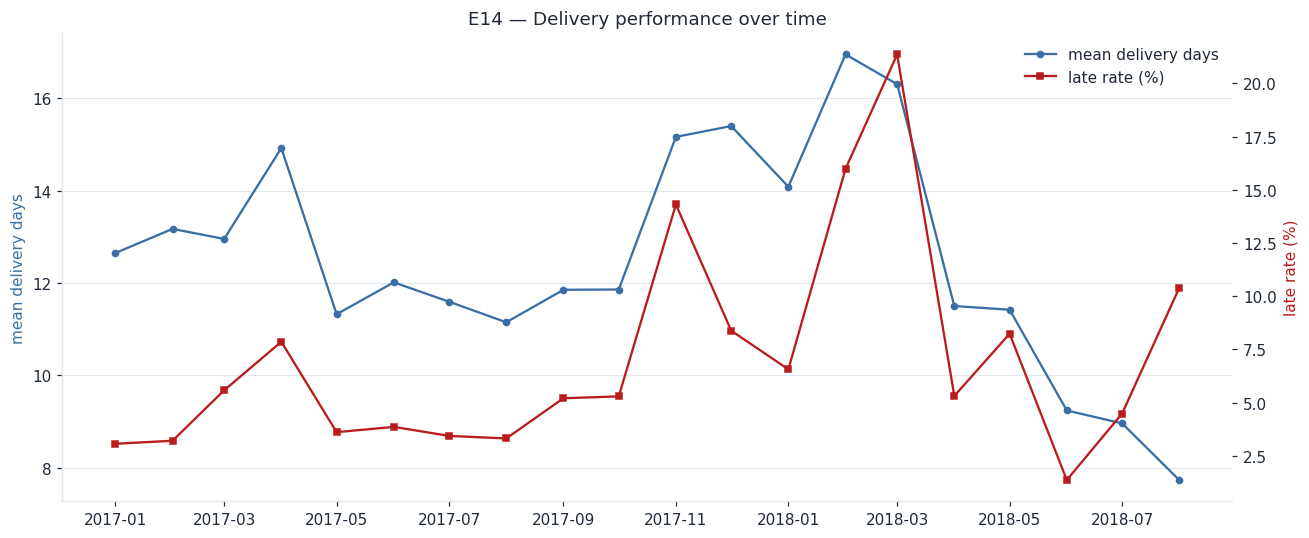

In [21]:
d = order_frame[order_frame["is_fulfilled"] & order_frame["delivery_days"].notna()]
d = d[(d["order_purchase_timestamp"] >= ANALYSIS_START)
      & (d["order_purchase_timestamp"] <= ANALYSIS_END)]

drift = d.set_index("order_purchase_timestamp").resample("MS").agg(
    mean_delivery_days=("delivery_days", "mean"),
    late_rate=("is_late", "mean"),
    mean_review=("review_score", "mean"),
    orders=("order_id", "count"),
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(drift.index, drift["mean_delivery_days"], marker="o", ms=4,
        color=PALETTE[0], label="mean delivery days")
ax.set_ylabel("mean delivery days", color=PALETTE[0])
ax2 = ax.twinx()
ax2.plot(drift.index, drift["late_rate"] * 100, marker="s", ms=4,
         color=PALETTE[3], label="late rate (%)")
ax2.set_ylabel("late rate (%)", color=PALETTE[3])
ax2.grid(False)
ax.set_title("E14 — Delivery performance over time")
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [ln.get_label() for ln in lines], loc="upper right")
fig.tight_layout()

display(drift.round(4))
print(f"\nlate rate range: {drift['late_rate'].min():.2%} to {drift['late_rate'].max():.2%}")
show(fig, "e14_delivery_drift")

---
# Section F — Pricing and payments

Olist has **no discount, coupon or list-price columns**, so there is no honest
discount analysis to run. Rather than invent a proxy and call it a discount, we
analyse payment structure: installment count is a strong price-sensitivity
proxy in Brazil, and it is known at order time — which makes it usable as a
churn feature.

## F15. Does installment behaviour signal value or return likelihood?

,orders,median_revenue,mean_review,repeat_rate,customers
installment_group,,,,,
1,46814,59.990,4.1893,0.0185,46163
2,12026,89.990,4.1734,0.0174,11897
3,10133,91.490,4.1179,0.0183,9983
4-6,15739,107.800,4.1263,0.0201,15446
7-10,11434,179.495,4.0806,0.0235,11180
11+,329,185.000,3.9350,0.0223,314


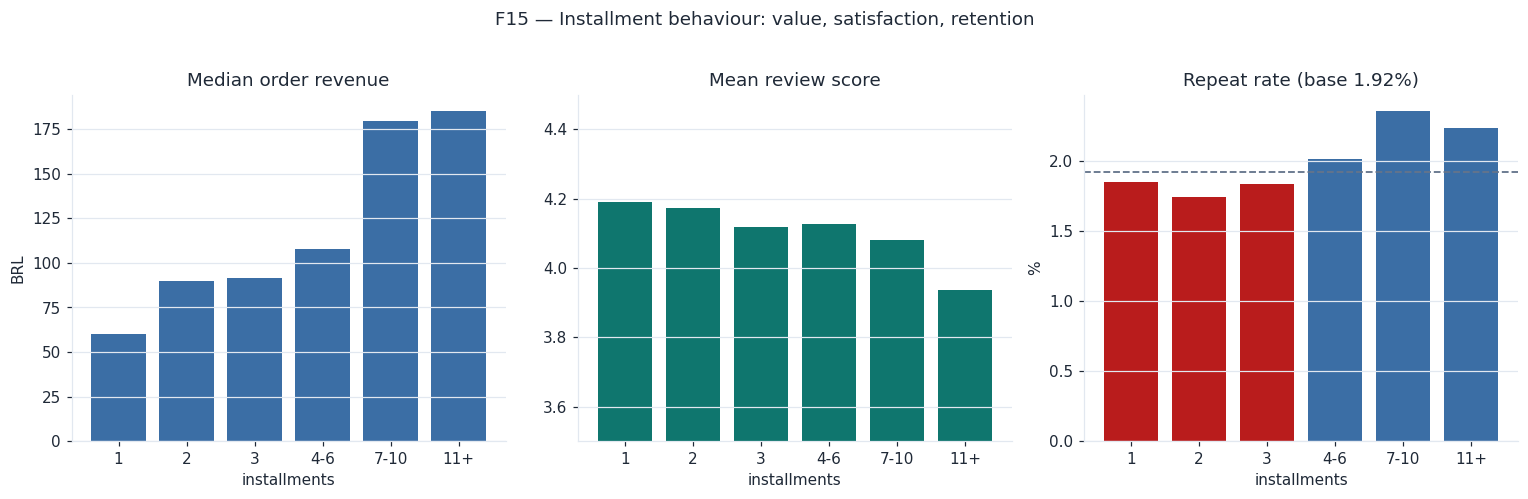

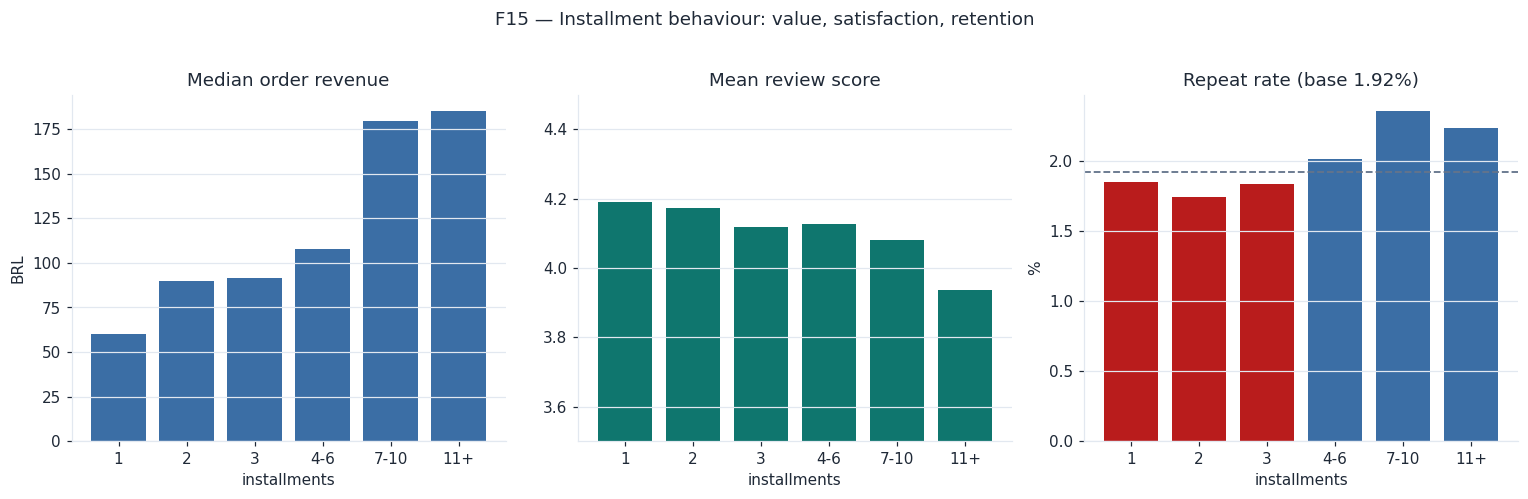

In [22]:
INSTALLMENT_BINS = [0, 1, 2, 3, 6, 10, 100]
INSTALLMENT_LABELS = ["1", "2", "3", "4-6", "7-10", "11+"]

d = order_frame[order_frame["is_fulfilled"] & order_frame["max_installments"].notna()].copy()
d["installment_group"] = pd.cut(d["max_installments"], bins=INSTALLMENT_BINS,
                                labels=INSTALLMENT_LABELS)
order_stats = d.groupby("installment_group", observed=True).agg(
    orders=("order_id", "count"),
    median_revenue=("revenue", "median"),
    mean_review=("review_score", "mean"),
)

# Repeat rate must come from the leakage-safe first-order frame.
fo = first_orders[first_orders["max_installments"].notna()].copy()
fo["installment_group"] = pd.cut(fo["max_installments"], bins=INSTALLMENT_BINS,
                                 labels=INSTALLMENT_LABELS)
repeat = fo.groupby("installment_group", observed=True)["repeated"].agg(
    repeat_rate="mean", customers="size"
)
inst = order_stats.join(repeat)

x = np.arange(len(inst))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
axes[0].bar(x, inst["median_revenue"], color=PALETTE[0])
axes[0].set_title("Median order revenue"); axes[0].set_ylabel("BRL")
axes[1].bar(x, inst["mean_review"], color=PALETTE[2])
axes[1].set_ylim(3.5, 4.5); axes[1].set_title("Mean review score")
colours = [PALETTE[0] if r >= BASE_RATE else PALETTE[3] for r in inst["repeat_rate"]]
axes[2].bar(x, inst["repeat_rate"] * 100, color=colours)
axes[2].axhline(BASE_RATE * 100, color=PALETTE[5], ls="--", lw=1.2)
axes[2].set_title(f"Repeat rate (base {BASE_RATE:.2%})"); axes[2].set_ylabel("%")
for ax in axes:
    ax.set_xticks(x, inst.index); ax.set_xlabel("installments")
fig.suptitle("F15 — Installment behaviour: value, satisfaction, retention", y=1.02)
fig.tight_layout()

display(inst.round(4))
show(fig, "f15_installment_behaviour")

## F16. Is there price-band structure worth segmenting on?

**Chart:** box plots on a log y-axis. You are comparing distributions across
many groups and need medians, spread and outliers simultaneously — which a bar
of means throws away.

,count,25%,50%,75%,max
category,,,,,
telephony,4545.0,21.99,29.99,49.00,2428.00
housewares,6964.0,32.00,59.80,114.10,6735.00
garden_tools,4347.0,49.90,59.90,99.90,3930.00
furniture_decor,8334.0,39.90,65.49,99.90,1899.00
sports_leisure,8641.0,44.32,78.00,129.99,4059.00
bed_bath_table,11115.0,47.99,79.05,115.00,1999.98
health_beauty,9670.0,39.99,79.90,129.90,3124.00
toys,4117.0,47.88,79.90,129.90,1699.99
computers_accessories,7827.0,39.90,81.99,149.00,3699.99


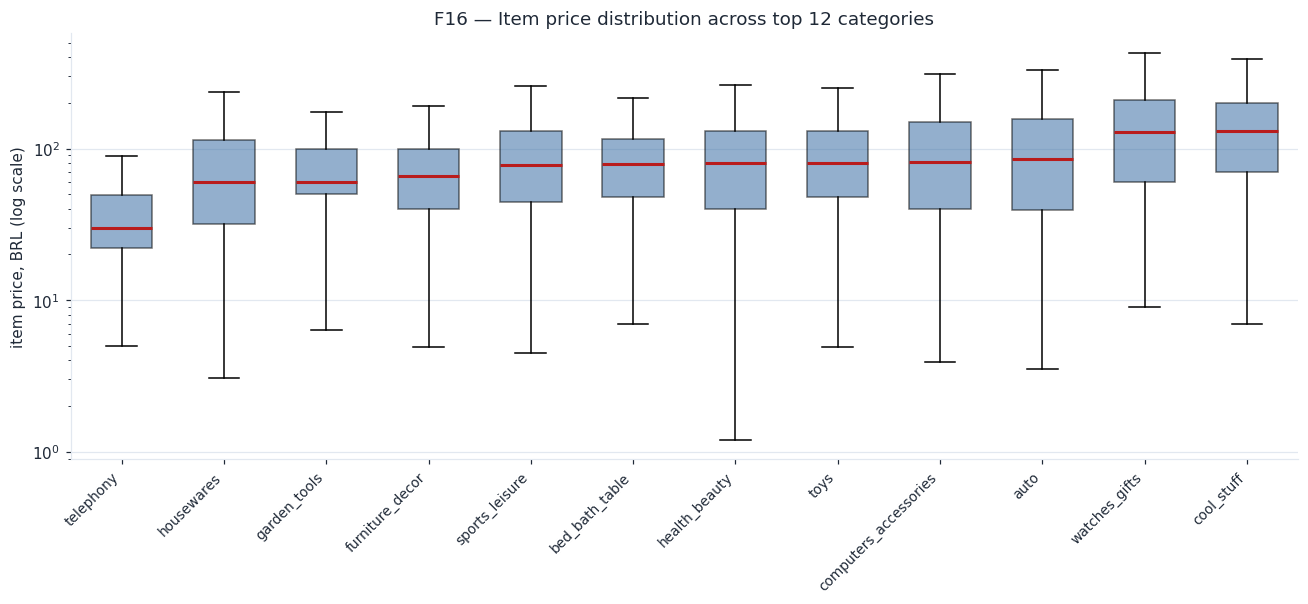

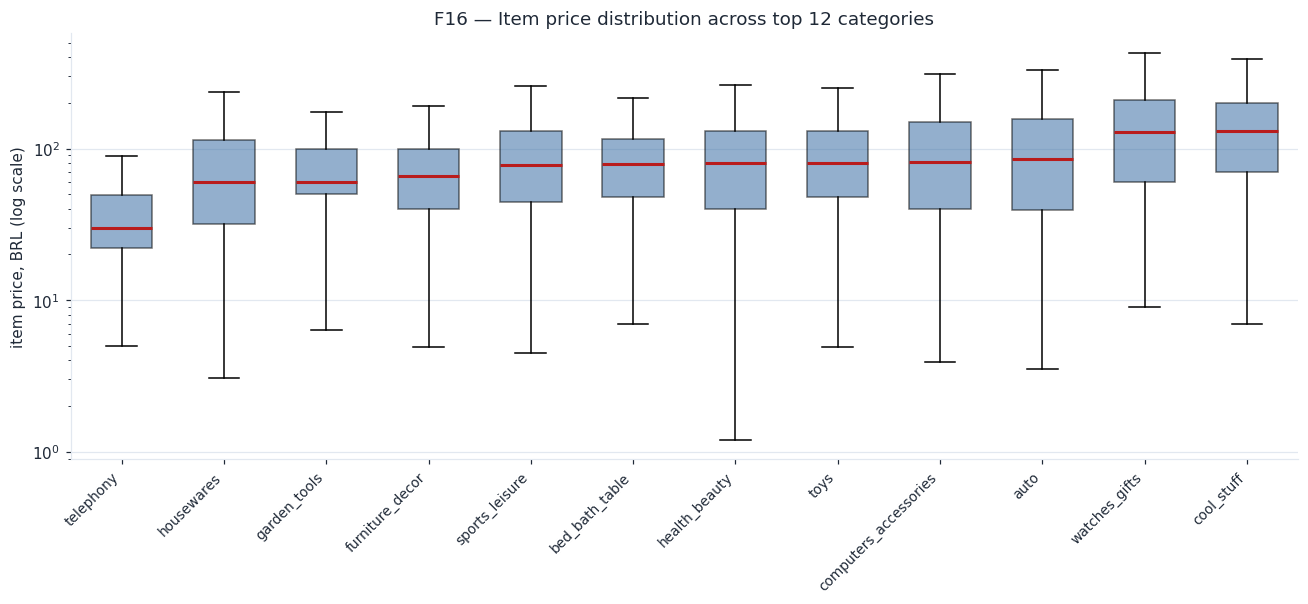

In [23]:
items = tables["order_items"].merge(
    tables["products"][["product_id", "product_category_name"]],
    on="product_id", how="left",
)
items = items[items["price"].gt(0) & items["product_category_name"].notna()].copy()
items["category"] = items["product_category_name"].map(labels_map).fillna(
    items["product_category_name"]
)

keys = items["category"].value_counts().head(12).index
sub = items[items["category"].isin(keys)]
order = sub.groupby("category", observed=True)["price"].median().sort_values()
data = [sub.loc[sub["category"] == c, "price"].to_numpy() for c in order.index]

fig, ax = plt.subplots(figsize=(12, 5.6))
bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.6)
for patch in bp["boxes"]:
    patch.set_facecolor(PALETTE[0]); patch.set_alpha(0.55)
for m in bp["medians"]:
    m.set_color(PALETTE[3]); m.set_linewidth(2)
ax.set_yscale("log")
ax.set_xticks(range(1, len(order) + 1), order.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("item price, BRL (log scale)")
ax.set_title("F16 — Item price distribution across top 12 categories")
fig.tight_layout()

display(sub.groupby("category", observed=True)["price"]
        .describe(percentiles=[0.25, 0.5, 0.75])
        .loc[order.index][["count", "25%", "50%", "75%", "max"]].round(2))
show(fig, "f16_price_bands")

---
# Section G — Reviews

## G17. What drives review scores?

**Why it matters:** review score is your secondary prediction target and a
churn feature, so you need its drivers before modelling.

**Chart:** binned means, not a scatter. `review_score` is a 1–5 ordinal;
scattering it against a continuous variable produces an unreadable lattice.
Sample sizes are annotated because some buckets are small.

**Look for:** whether this is a cliff or a slope.

,mean_review,pct_one_star,n
lateness_bucket,,,
30+ early,4.2537,0.0813,2337
20-30 early,4.2956,0.0731,11072
15-20 early,4.3437,0.0606,16044
10-15 early,4.3268,0.0624,27452
5-10 early,4.2775,0.0645,22442
0-5 early,4.1521,0.0771,8816
1-3 late,3.7659,0.1377,2636
3-7 late,2.3181,0.5302,1773
7-15 late,1.7298,0.6865,1917


mean review on time  4.2940
mean review late     2.5653
1-star on time       0.0659
1-star late          0.4622
low-review base rate 0.1281
Pearson r (lateness, score) -0.2668


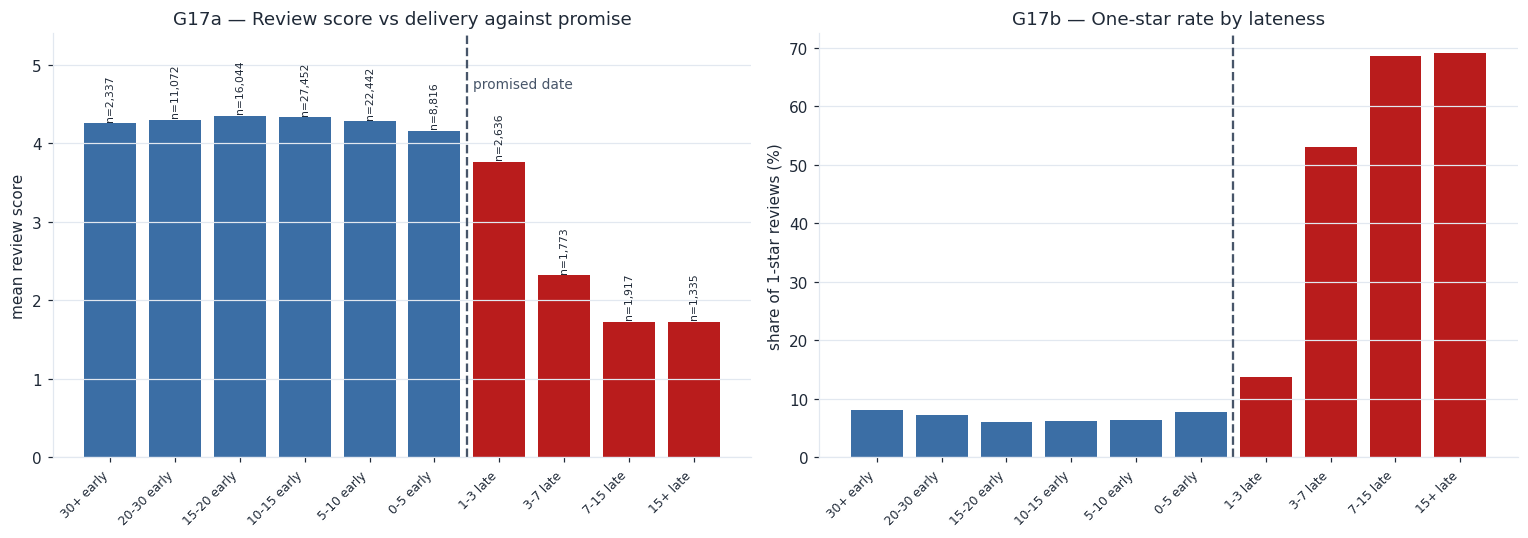

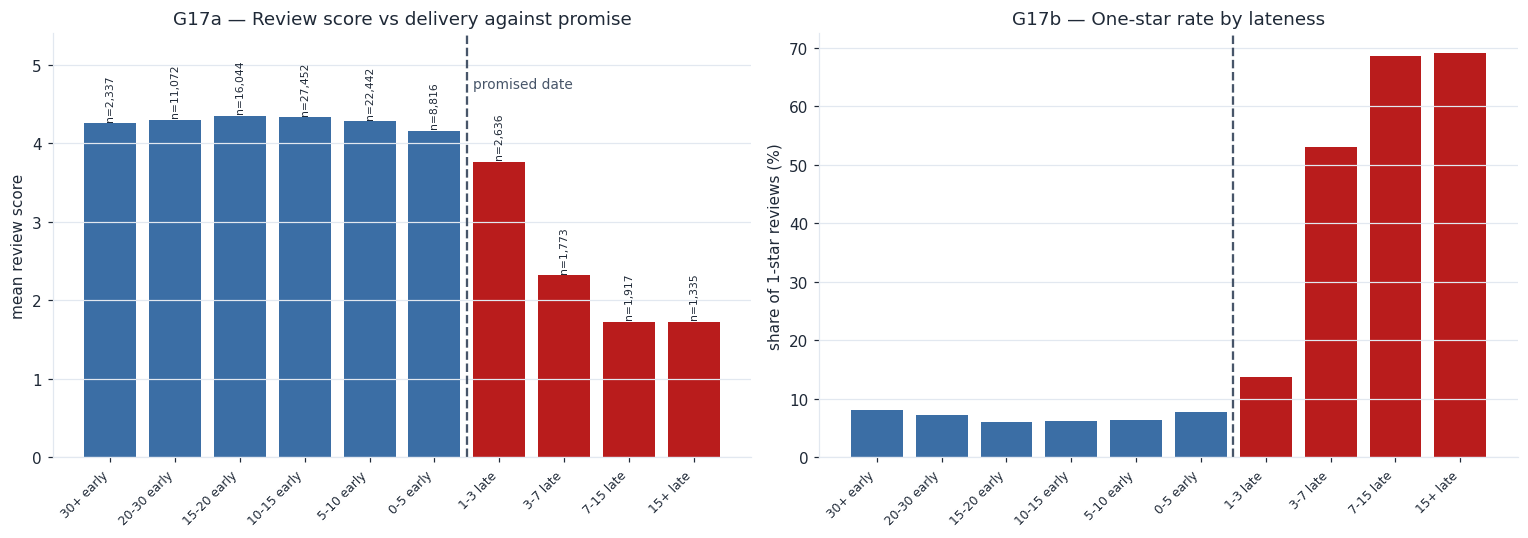

In [24]:
LATENESS_BINS = [-np.inf, -30, -20, -15, -10, -5, 0, 3, 7, 15, np.inf]
LATENESS_LABELS = ["30+ early", "20-30 early", "15-20 early", "10-15 early",
                   "5-10 early", "0-5 early", "1-3 late", "3-7 late",
                   "7-15 late", "15+ late"]

d = order_frame[
    order_frame["is_fulfilled"]
    & order_frame["review_score"].notna()
    & order_frame["estimate_error_days"].notna()
].copy()
d["lateness_bucket"] = pd.cut(d["estimate_error_days"], bins=LATENESS_BINS,
                              labels=LATENESS_LABELS)

lateness = d.groupby("lateness_bucket", observed=True).agg(
    mean_review=("review_score", "mean"),
    pct_one_star=("review_score", lambda s: (s == 1).mean()),
    n=("order_id", "count"),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colours = [PALETTE[3] if "late" in str(i) else PALETTE[0] for i in lateness.index]

bars = axes[0].bar(range(len(lateness)), lateness["mean_review"], color=colours)
axes[0].axvline(5.5, color="#475569", ls="--", lw=1.5)
axes[0].text(5.6, 4.7, "promised date", fontsize=9, color="#475569")
for bar, n in zip(bars, lateness["n"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.06,
                 f"n={n:,}", ha="center", fontsize=7, rotation=90)
axes[0].set_xticks(range(len(lateness)), lateness.index, rotation=45, ha="right",
                   fontsize=8)
axes[0].set_ylim(0, 5.4); axes[0].set_ylabel("mean review score")
axes[0].set_title("G17a — Review score vs delivery against promise")

axes[1].bar(range(len(lateness)), lateness["pct_one_star"] * 100, color=colours)
axes[1].axvline(5.5, color="#475569", ls="--", lw=1.5)
axes[1].set_xticks(range(len(lateness)), lateness.index, rotation=45, ha="right",
                   fontsize=8)
axes[1].set_ylabel("share of 1-star reviews (%)")
axes[1].set_title("G17b — One-star rate by lateness")
fig.tight_layout()

on_time, late = d.loc[~d["is_late"], "review_score"], d.loc[d["is_late"], "review_score"]
display(lateness.round(4))
print(f"mean review on time  {on_time.mean():.4f}")
print(f"mean review late     {late.mean():.4f}")
print(f"1-star on time       {(on_time == 1).mean():.4f}")
print(f"1-star late          {(late == 1).mean():.4f}")
print(f"low-review base rate {d['review_score'].le(2).mean():.4f}")
print(f"Pearson r (lateness, score) {d[['estimate_error_days','review_score']].corr().iloc[0,1]:.4f}")
show(fig, "g17_review_drivers")

Note the tension: the effect is enormous but Pearson r is only about −0.27.
That is *because* the relationship is a step function rather than linear — the
argument for tree-based models and explicit threshold features rather than
feeding raw day counts to a linear model.

## G18. Who writes reviews, and is the text corpus biased?

**Why it matters:** only 41% of reviews carry text. If unhappy customers write
more, your sentiment model cannot be reported as measuring overall
satisfaction, and `has_comment` becomes a feature in its own right.

,reviews,comment_rate,mean_length
review_score,,,
1.0,11365,0.766036,99.9240
2.0,3130,0.68115,96.7688
3.0,8134,0.434841,83.2055
4.0,19043,0.312451,61.7395
5.0,57001,0.358783,51.8485


overall comment rate        0.4132
bias ratio (1-star/5-star)  2.1351
low scores, all reviews     0.1469
low scores, with text only  0.2658


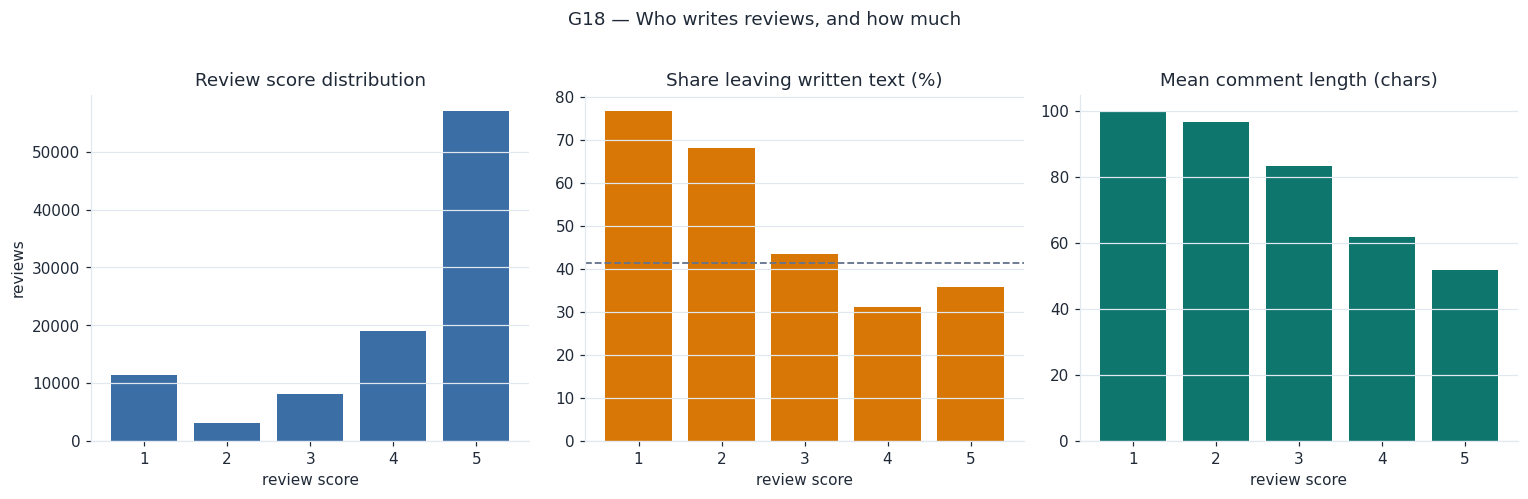

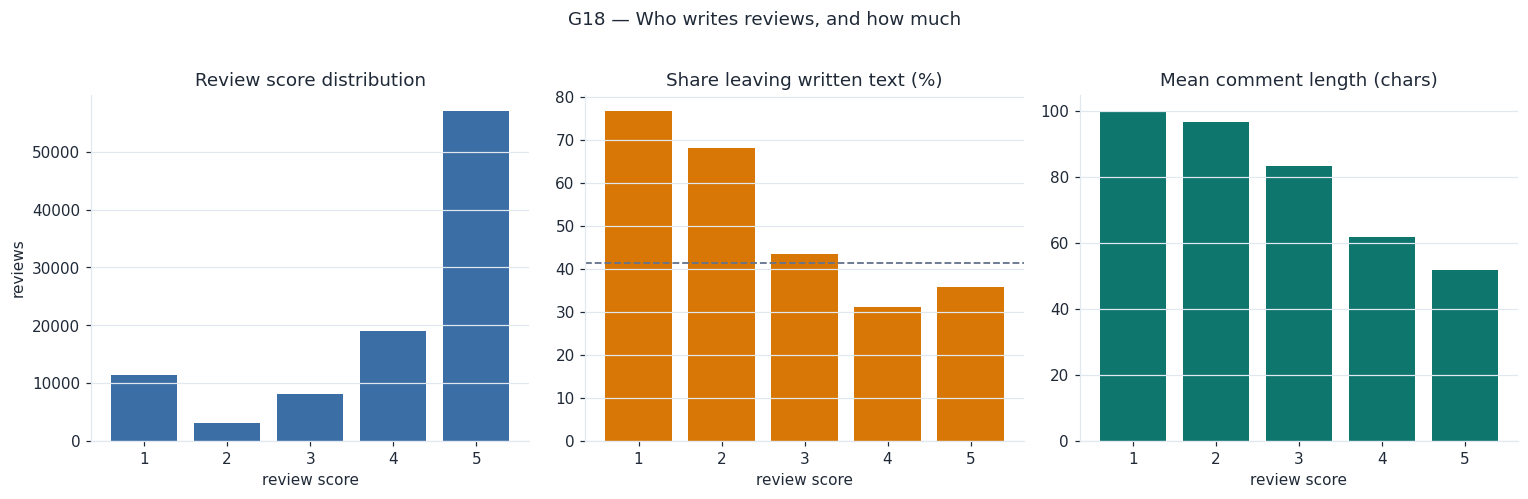

In [25]:
d = order_frame[order_frame["review_score"].notna()].copy()

comment_stats = d.groupby("review_score", observed=True).agg(
    reviews=("order_id", "count"),
    comment_rate=("has_comment", "mean"),
    mean_length=("comment_length", lambda s: s[s > 0].mean()),
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
scores = comment_stats.index.astype(int)
axes[0].bar(scores, comment_stats["reviews"], color=PALETTE[0])
axes[0].set_title("Review score distribution"); axes[0].set_ylabel("reviews")
axes[1].bar(scores, comment_stats["comment_rate"] * 100, color=PALETTE[1])
axes[1].axhline(d["has_comment"].mean() * 100, color=PALETTE[5], ls="--", lw=1.2)
axes[1].set_title("Share leaving written text (%)")
axes[2].bar(scores, comment_stats["mean_length"], color=PALETTE[2])
axes[2].set_title("Mean comment length (chars)")
for ax in axes:
    ax.set_xticks(scores); ax.set_xlabel("review score")
fig.suptitle("G18 — Who writes reviews, and how much", y=1.02)
fig.tight_layout()

with_text = d[d["has_comment"]]
display(comment_stats.round(4))
print(f"overall comment rate        {d['has_comment'].mean():.4f}")
print(f"bias ratio (1-star/5-star)  "
      f"{comment_stats.loc[1,'comment_rate'] / comment_stats.loc[5,'comment_rate']:.4f}")
print(f"low scores, all reviews     {d['review_score'].le(2).mean():.4f}")
print(f"low scores, with text only  {with_text['review_score'].le(2).mean():.4f}")
show(fig, "g18_comment_bias")

---
# Section H — Retention and churn indicators

## H19. What does the repeat-purchase funnel actually look like?

**Why it matters:** this is the foundation of your churn definition and the
number everyone will question. Of the customers with a second order, a large
share placed it within 24 hours across multiple sellers — those are single
shopping sessions split into separate `order_id`s by the marketplace, not
returning customers.

customers                94,986
raw repeat rate          0.0304
corrected repeat rate    0.0192
basket splits removed    1,063
median genuine gap       91.0 days


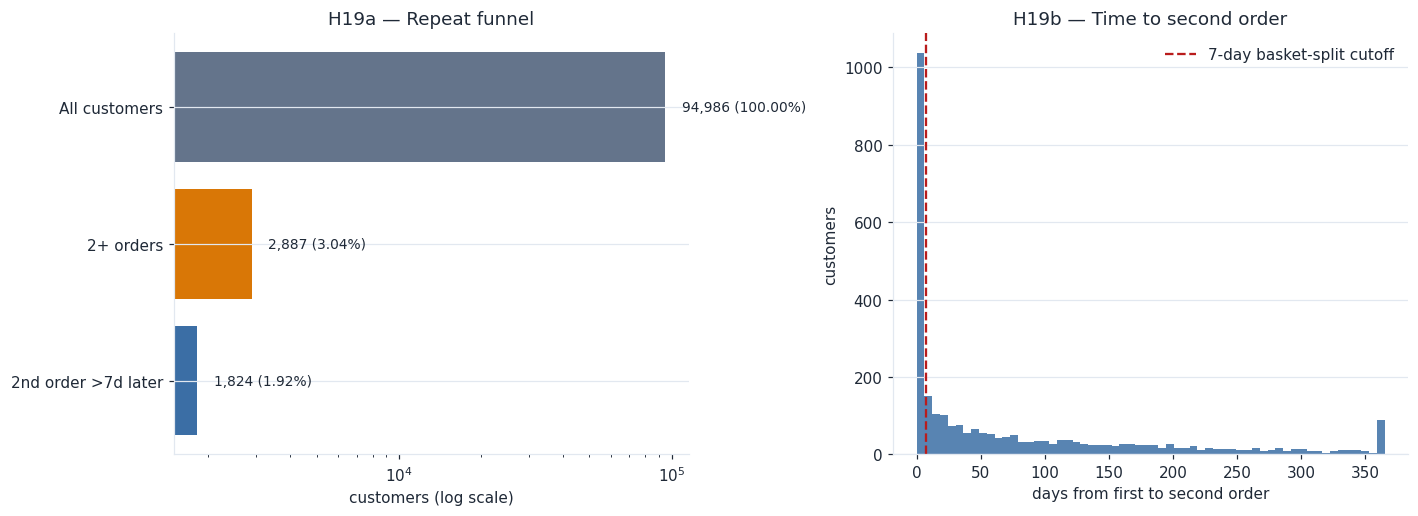

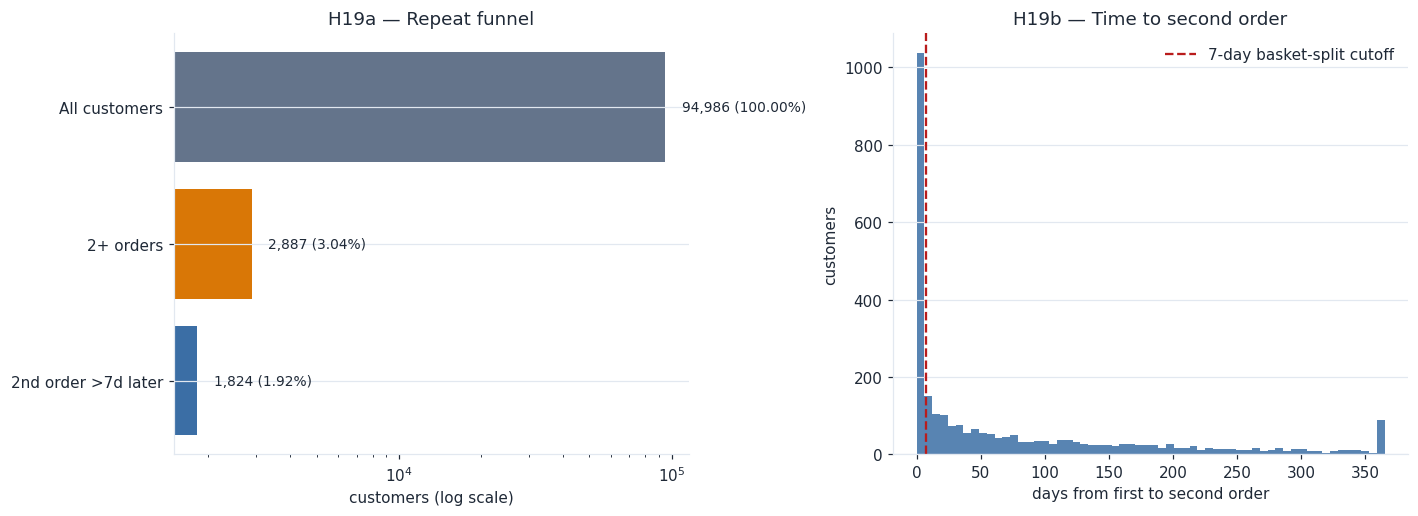

In [26]:
REPEAT_GAP_DAYS = 7

n_all = len(customer_frame)
n_raw = int(customer_frame["is_repeat_raw"].sum())
n_true = int(customer_frame["is_repeat"].fillna(False).sum())
gaps = customer_frame["days_to_second_order"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

labels = ["All customers", "2+ orders", f"2nd order >{REPEAT_GAP_DAYS}d later"]
values = [n_all, n_raw, n_true]
bars = axes[0].barh(range(3), values, color=[PALETTE[5], PALETTE[1], PALETTE[0]])
axes[0].set_yticks(range(3), labels)
axes[0].invert_yaxis()
axes[0].set_xscale("log")   # 95k vs 1.8k on a linear axis is invisible
axes[0].set_xlabel("customers (log scale)")
axes[0].set_title("H19a — Repeat funnel")
for bar, v in zip(bars, values):
    axes[0].text(v * 1.15, bar.get_y() + bar.get_height() / 2,
                 f"{v:,} ({v / n_all:.2%})", va="center", fontsize=9)

axes[1].hist(gaps.clip(upper=365), bins=60, color=PALETTE[0], alpha=0.85)
axes[1].axvline(REPEAT_GAP_DAYS, color=PALETTE[3], ls="--", lw=1.5,
                label=f"{REPEAT_GAP_DAYS}-day basket-split cutoff")
axes[1].set_xlabel("days from first to second order")
axes[1].set_ylabel("customers")
axes[1].set_title("H19b — Time to second order")
axes[1].legend()
fig.tight_layout()

print(f"customers                {n_all:,}")
print(f"raw repeat rate          {n_raw / n_all:.4f}")
print(f"corrected repeat rate    {n_true / n_all:.4f}")
print(f"basket splits removed    {n_raw - n_true:,}")
print(f"median genuine gap       {gaps[gaps > REPEAT_GAP_DAYS].median():.1f} days")
show(fig, "h19_repeat_funnel")

## H20. Which first-order characteristics separate returners from churners?

**Why it matters:** this is your churn model's feature shortlist, chosen by
evidence rather than guesswork.

**Chart:** small multiples with the base rate drawn as a reference line. At a
1.9% base rate, any effect is invisible on an absolute scale — you need
relative comparison against a reference.

Uses `first_orders`, never `customer_frame`. That is the leakage guard.

,feature,min_rate,max_rate,spread_pp,relative_lift
0,n_items,0.0185,0.0314,1.2932,1.6998
1,primary_category,0.0154,0.0261,1.0664,1.6910
2,estimate_error_days,0.0141,0.0220,0.7848,1.5546
3,review_score,0.0148,0.0209,0.6123,1.4151
4,max_installments,0.0174,0.0226,0.5210,1.2994
5,delivery_days,0.0165,0.0204,0.3923,1.2383
6,customer_state,0.0176,0.0217,0.4032,1.2288
7,freight_ratio,0.0180,0.0214,0.3410,1.1894
8,revenue,0.0179,0.0203,0.2325,1.1295


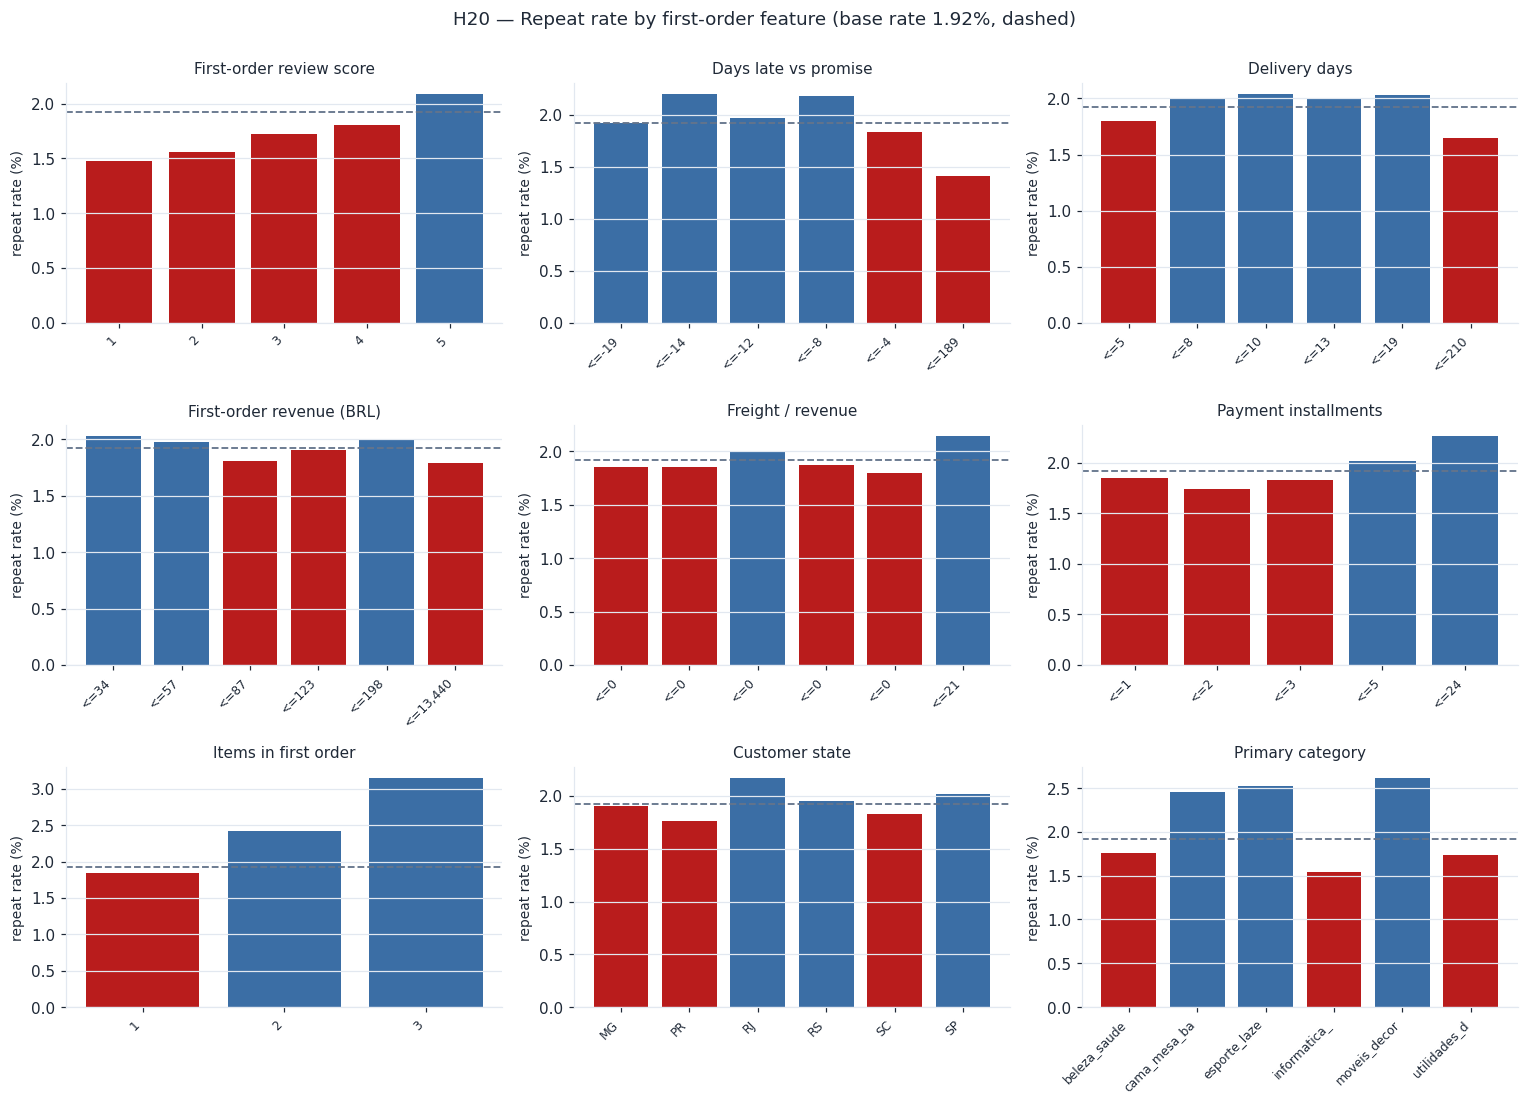

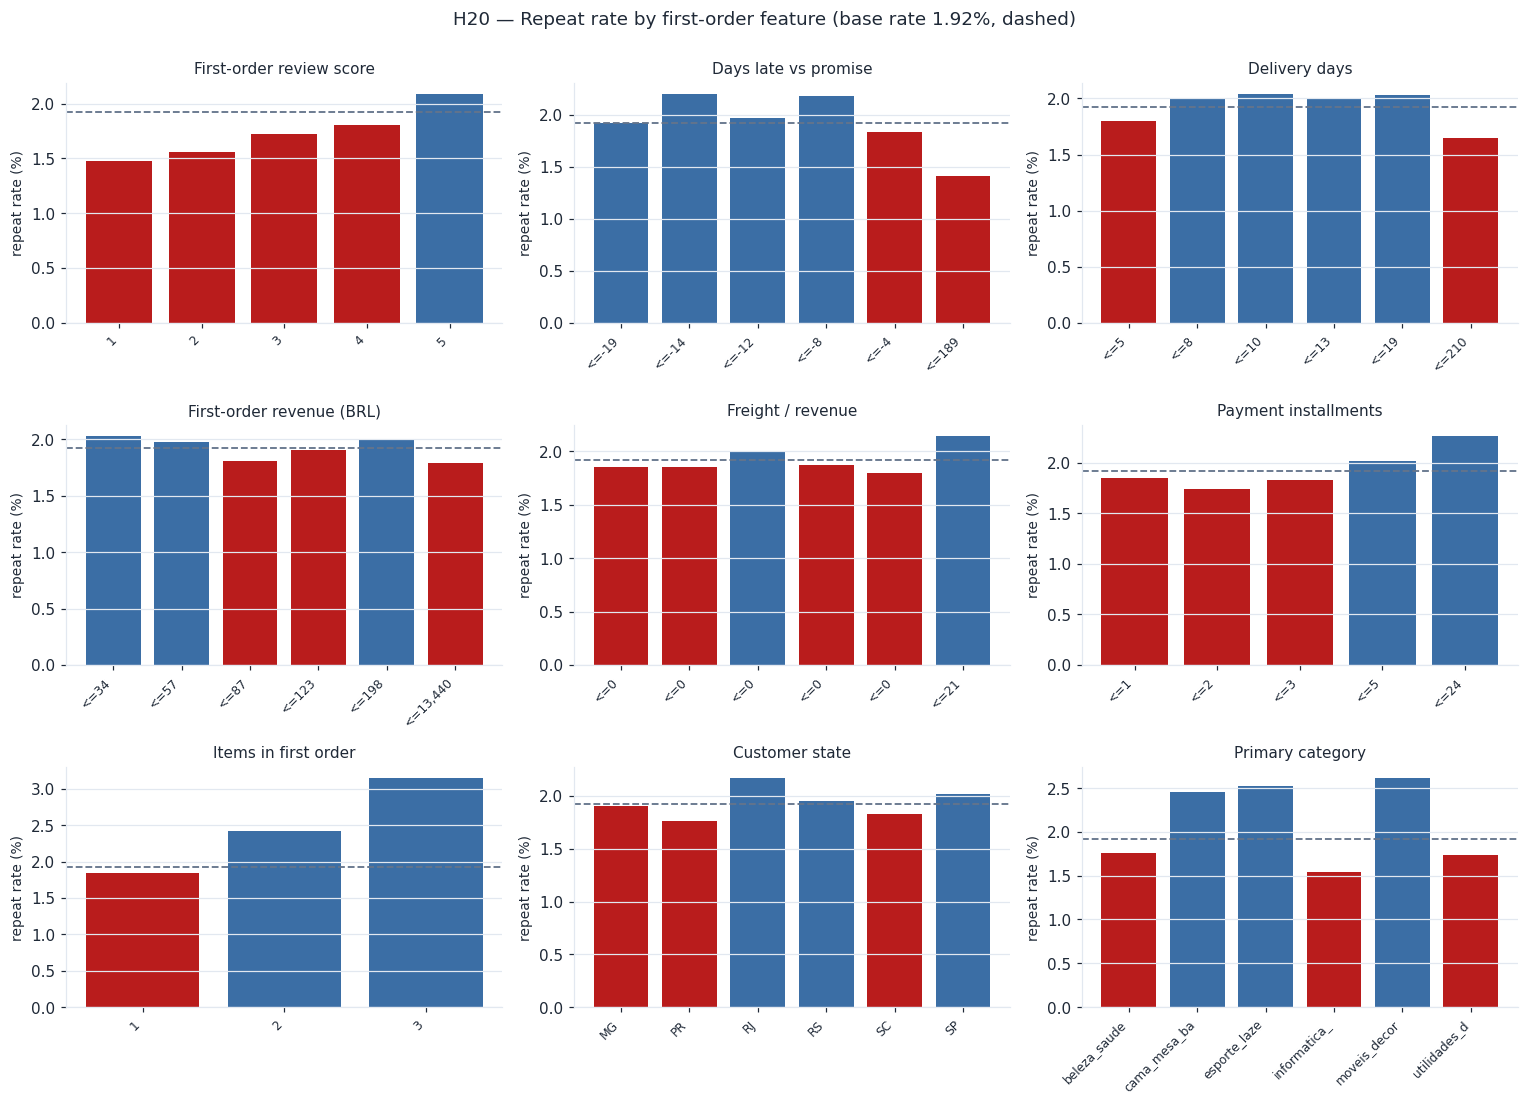

In [27]:
def bucket_repeat_rate(df, column, bins=6, categorical=False, min_n=100):
    """Repeat rate per bucket of one feature.

    Three strategies, chosen by the shape of the column:
      categorical  -> the `bins` most common values
      few distinct -> group by raw value
      continuous   -> qcut (equal-COUNT buckets, not equal-width; on skewed
                      money columns equal-width puts all mass in bucket one)

    The degenerate-bin fallback matters: n_items spans 1-21 so it looks
    continuous, but ~90% of orders contain exactly one item, so every quantile
    edge lands on 1.0 and collapses to a single bucket -- silently reporting
    "no signal" rather than crashing.
    """
    sub = df[[column, "repeated"]].dropna(subset=[column])

    if categorical:
        keys = sub[column].value_counts().head(bins).index
        sub = sub[sub[column].isin(keys)]
        grouped = sub.groupby(column, observed=True)
    elif sub[column].nunique() <= 8:
        grouped = sub.groupby(sub[column].astype(int), observed=True)
    else:
        buckets = None
        try:
            buckets = pd.qcut(sub[column], q=bins, duplicates="drop")
        except ValueError:
            pass
        if buckets is None or buckets.nunique() < 3:
            capped = sub[column].clip(upper=sub[column].quantile(0.99))
            buckets = (capped.round().astype(int) if capped.nunique() <= 12
                       else pd.cut(capped, bins=bins))
        grouped = sub.groupby(buckets, observed=True)

    out = grouped["repeated"].agg(repeat_rate="mean", n="size")
    return out[out["n"] >= min_n]


def bucket_labels(index):
    if len(index) and isinstance(index[0], pd.Interval):
        return [f"<={iv.right:,.0f}" for iv in index]
    return [str(i)[:12] for i in index]


FEATURES = [
    ("review_score", False, "First-order review score"),
    ("estimate_error_days", False, "Days late vs promise"),
    ("delivery_days", False, "Delivery days"),
    ("revenue", False, "First-order revenue (BRL)"),
    ("freight_ratio", False, "Freight / revenue"),
    ("max_installments", False, "Payment installments"),
    ("n_items", False, "Items in first order"),
    ("customer_state", True, "Customer state"),
    ("primary_category", True, "Primary category"),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
results = {}

for ax, (col, is_cat, title) in zip(axes.ravel(), FEATURES):
    tbl = bucket_repeat_rate(first_orders, col, bins=6, categorical=is_cat)
    results[col] = tbl
    colours = [PALETTE[0] if r >= BASE_RATE else PALETTE[3]
               for r in tbl["repeat_rate"]]
    ax.bar(range(len(tbl)), tbl["repeat_rate"] * 100, color=colours)
    ax.axhline(BASE_RATE * 100, color=PALETTE[5], ls="--", lw=1.2)
    ax.set_xticks(range(len(tbl)), bucket_labels(tbl.index), rotation=45,
                  ha="right", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("repeat rate (%)", fontsize=9)

fig.suptitle(f"H20 — Repeat rate by first-order feature "
             f"(base rate {BASE_RATE:.2%}, dashed)", y=1.00)
fig.tight_layout()

# Rank by RATIO, not difference: at a ~2% base rate a 1pp swing is a 50%
# relative change, which matters but looks like nothing on an absolute scale.
lift = pd.DataFrame([
    {"feature": col,
     "min_rate": t["repeat_rate"].min(),
     "max_rate": t["repeat_rate"].max(),
     "spread_pp": (t["repeat_rate"].max() - t["repeat_rate"].min()) * 100,
     "relative_lift": (t["repeat_rate"].max() / t["repeat_rate"].min()
                       if t["repeat_rate"].min() > 0 else np.inf)}
    for col, t in results.items() if not t.empty
]).sort_values("relative_lift", ascending=False).reset_index(drop=True)

display(lift.round(4))
show(fig, "h20_repeat_drivers")

---
# What the EDA specified for the feature layer

Every lift in H20 is under 2x. That is the honest early warning: the churn
model will have modest discrimination. Better to know it now than to discover
it while modelling.

Four requirements this EDA established:

1. **Threshold features around the promised delivery date** — G17 shows a
   cliff, not a slope, so raw day counts under-represent the effect.
2. **Order-month controls** — E14 shows the late rate swinging between about
   1% and 21% by month. Without controls the model learns a time trend and
   reports it as a delivery effect.
3. **`has_comment` as a feature** — G18 shows comment presence is over twice as
   likely on 1-star reviews.
4. **`is_late` flagged unreliable for multi-seller orders** — B6's
   contradiction indicates the delivery timestamp records one shipment, not the
   last.

Analysis window is fixed at **2017-01-01 to 2018-08-31** for every later phase.